<a href="https://colab.research.google.com/github/alex-degarate/ML/blob/main/pre_entrega/shabikes4f2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<font color="darkred">Version: 4h6   &emsp; &emsp; &emsp; &emsp;2026-07-06
</font>   

<font face="Times"><font size="44">
# Análisis de Alquiler de bicicletas </font></font>
    
## Alejandro de Gárate &emsp; &emsp; &emsp;Comisión #26140&emsp; &emsp; &emsp;  

![Bicicletas](https://github.com/alex-degarate/ML/raw/refs/heads/main/pre_entrega/bikes.png)

Bike Sharing Dataset from:
kaggle/akshmi25npathi/bike-sharing-dataset

## **Antecedentes**

Los sistemas de bicicletas compartidas representan la nueva generación de
alquileres de bicicletas tradicionales, donde todo el proceso, desde la
inscripción y el alquiler hasta la devolución, se ha automatizado.   

Mediante estos sistemas, el usuario puede alquilar fácilmente una bicicleta en
una ubicación determinada y devolverla en otra. Actualmente, existen más de
500 programas de bicicletas compartidas en todo el mundo, que suman más de
500.000 bicicletas. Hoy en día, existe un gran interés en estos sistemas
debido a su importante papel en la gestión del tráfico, el medio ambiente y
la salud.

<br>

Además de las interesantes aplicaciones prácticas de los sistemas de bicicletas
compartidas, las características de los datos que generan los hacen atractivos
para la investigación.    
A diferencia de otros servicios de transporte como el
autobús o el metro, la duración del viaje, la posición de salida y la de
llegada se registran explícitamente en estos sistemas.  
Esta característica convierte al sistema de bicicletas compartidas en una red
de sensores virtuales que puede utilizarse para monitorizar la movilidad en la
ciudad. Por lo tanto, se espera que la mayoría de los eventos importantes de la
ciudad puedan detectarse mediante el monitoreo de estos datos.

<font color="#008000"> *He elegido este dataset porque ando en bicicleta, me resultó interesante y sale de lo habitual* </font>

## Dataset

El proceso de alquiler de bicicletas compartidas está altamente correlacionado
con las condiciones ambientales y estacionales.   
Por ejemplo, las condiciones climáticas, las precipitaciones, el día de la semana, la estación del año, la hora del día, etc., pueden afectar el comportamiento de los usuarios.

El conjunto de datos principal se relaciona con el registro histórico de dos
años correspondiente a los años 2011 y 2012 del sistema Capital Bikeshare,
Washington D.C., EE. UU.   
Que está disponible públicamente en http://capitalbikeshare.com/system-data.   
Agregamos los datos por hora y por día, y luego extrajimos y añadimos la
información climática y estacional correspondiente.
La información climática se extrajo de http://www.freemeteo.com.

<font color="red">NOTA:</font> (del programador)

El dataset original fue sacado de kaggle, pero debido a que ya tenia columnas manipuladas, se prefirió llevarla a un estado más básico, para ser procesadas.

Por esta razón vamos a partir de otro dataset, pero básicamente con la misma información.

In [1]:
# Importamos las libreria necesaria para trabajar
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

# Libreria de warnings nos asistiran para ignorar warnings inocuos
import warnings
warnings.filterwarnings('ignore')
from IPython.display import HTML
import json

# librarias usadas en pre-procesamiento
from sklearn import preprocessing, linear_model
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

# libraries para evaluar performance
from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, mean_absolute_error


# PARTE I (pre-Entrega)

##1. Recolección y Comprensión de los datos

In [2]:
ruta = "https://raw.githubusercontent.com/alex-degarate/ML/main/pre_entrega/"
df = pd.read_csv(ruta + 'hour_ini.csv', index_col=0)

In [ ]:
# Obtenemos el nombre de las columnas y el tipo de dato de cada una
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17379 entries, 0 to 17378
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   rental_date  17379 non-null  object 
 1   hour         17379 non-null  int64  
 2   feriado      17379 non-null  int64  
 3   clima        17379 non-null  int64  
 4   casual_usr   17379 non-null  int64  
 5   regist_usr   17379 non-null  int64  
 6   count        17379 non-null  int64  
 7   temp         17379 non-null  float64
 8   termic_sens  17379 non-null  float64
 9   humidity     17379 non-null  float64
 10  windspeed    17379 non-null  float64
dtypes: float64(4), int64(6), object(1)
memory usage: 1.6+ MB


**Columnas:**
<pre>
 0   rental_date  fecha de alquiler    (formato ISO)  
 1   hour         hora de alquiler     (0-24)
 2   feriado      si el dia es feriado (según Whashington DC - USA)      
 3   clima        tipo de clima        (tabla de categoria)   
 4   casual_usr   si el usuario es ocasional    
 5   regist_usr   si el usuario esta registrado  
 6   count        cantidad de bicicletas alquiladas en la hora   
 7   temp         temperatura          (grados Celsius)  
 8   termic_sens  sensacion térmica    (grados Celsius)  
 9   humidity     humedad ambiente     (porcentaje)  
10   windspeed    velocidad del viento (km/h)
</pre>

In [ ]:
# Visualizamos los primeros registros para tener una idea de los los datos
df.head()

,rental_date,hour,feriado,clima,casual_usr,regist_usr,count,temp,termic_sens,humidity,windspeed
0,2011-01-01,0,0,1,3,13,16,9.84,14.395,81.0,0.0
1,2011-01-01,1,0,1,8,32,40,9.02,13.635,80.0,0.0
2,2011-01-01,2,0,1,5,27,32,9.02,13.635,80.0,0.0
3,2011-01-01,3,0,1,3,10,13,9.84,14.395,75.0,0.0
4,2011-01-01,4,0,1,0,1,1,9.84,14.395,75.0,0.0


In [ ]:
df.shape
print("Cantidad de registros: ", df.shape[0])
print("Cantidad de  columnas: ", df.shape[1])

Cantidad de registros:  17379
Cantidad de  columnas:  11


## 2. EDA y limpieza de datos

In [ ]:
# Revisamos si hay datos nulos o faltantes
df.isnull().sum()

,0
rental_date,0
hour,0
feriado,0
clima,0
casual_usr,0
regist_usr,0
count,0
temp,0
termic_sens,0
humidity,0


No hay datos nulos, ni registros para descartar.

In [ ]:
# Revisamos si hay datos duplicados
print("datos duplicados:", df.duplicated().sum() )

datos duplicados: 0


No hay datos registros duplicados

In [ ]:
df.describe()

,hour,feriado,clima,casual_usr,regist_usr,count,temp,termic_sens,humidity,windspeed
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,11.546752,0.028770,1.425283,35.676218,153.786869,189.463088,20.376474,23.788755,62.722884,12.736540
std,6.914405,0.167165,0.639357,49.305030,151.357286,181.387599,7.894801,8.592511,19.292983,8.196795
min,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.820000,0.000000,0.000000,0.000000
25%,6.000000,0.000000,1.000000,4.000000,34.000000,40.000000,13.940000,16.665000,48.000000,7.001500
50%,12.000000,0.000000,1.000000,17.000000,115.000000,142.000000,20.500000,24.240000,63.000000,12.998000
75%,18.000000,0.000000,2.000000,48.000000,220.000000,281.000000,27.060000,31.060000,78.000000,16.997900
max,23.000000,1.000000,4.000000,367.000000,886.000000,977.000000,41.000000,50.000000,100.000000,56.996900


     
Antes de continuar con el EDA efectuamos algunas transformaciones básicas para poder analizarlo mejor.

In [ ]:
# Convertimos rental_date de object a datetime
df["rental_date"] = pd.to_datetime(df["rental_date"])

# extraemos el año a una columna nueva
df["year"] = df["rental_date"].dt.year

In [ ]:
# Vemos que años estan presentes
print(f"Años presentes: {df["year"].unique()} ")

Años presentes: [2011 2012] 


In [ ]:
# como vemos sólo hay dos años 2011 y 2012
# convertimos la columna en formato Binary 2011= 0, 2012= 1
df["year"] = df["year"] - 2011

In [ ]:
# creamos una columna month/mes en base 1-12
df["month"] = df["rental_date"].dt.month

In [ ]:
df.head(5)

,rental_date,hour,feriado,clima,casual_usr,regist_usr,count,temp,termic_sens,humidity,windspeed,year,month
0,2011-01-01,0,0,1,3,13,16,9.84,14.395,81.0,0.0,0,1
1,2011-01-01,1,0,1,8,32,40,9.02,13.635,80.0,0.0,0,1
2,2011-01-01,2,0,1,5,27,32,9.02,13.635,80.0,0.0,0,1
3,2011-01-01,3,0,1,3,10,13,9.84,14.395,75.0,0.0,0,1
4,2011-01-01,4,0,1,0,1,1,9.84,14.395,75.0,0.0,0,1


In [ ]:
df.describe()

,rental_date,hour,feriado,clima,casual_usr,regist_usr,count,temp,termic_sens,humidity,windspeed,year,month
count,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,2012-01-02 04:08:34.552045568,11.546752,0.028770,1.425283,35.676218,153.786869,189.463088,20.376474,23.788755,62.722884,12.736540,0.502561,6.537775
min,2011-01-01 00:00:00,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.820000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2011-07-04 00:00:00,6.000000,0.000000,1.000000,4.000000,34.000000,40.000000,13.940000,16.665000,48.000000,7.001500,0.000000,4.000000
50%,2012-01-02 00:00:00,12.000000,0.000000,1.000000,17.000000,115.000000,142.000000,20.500000,24.240000,63.000000,12.998000,1.000000,7.000000
75%,2012-07-02 00:00:00,18.000000,0.000000,2.000000,48.000000,220.000000,281.000000,27.060000,31.060000,78.000000,16.997900,1.000000,10.000000
max,2012-12-31 00:00:00,23.000000,1.000000,4.000000,367.000000,886.000000,977.000000,41.000000,50.000000,100.000000,56.996900,1.000000,12.000000
std,NaN,6.914405,0.167165,0.639357,49.305030,151.357286,181.387599,7.894801,8.592511,19.292983,8.196795,0.500008,3.438776


<font color="white">.</font>
### Vemos si algunas de las posibles variables predictoras siguen una distribución Normal

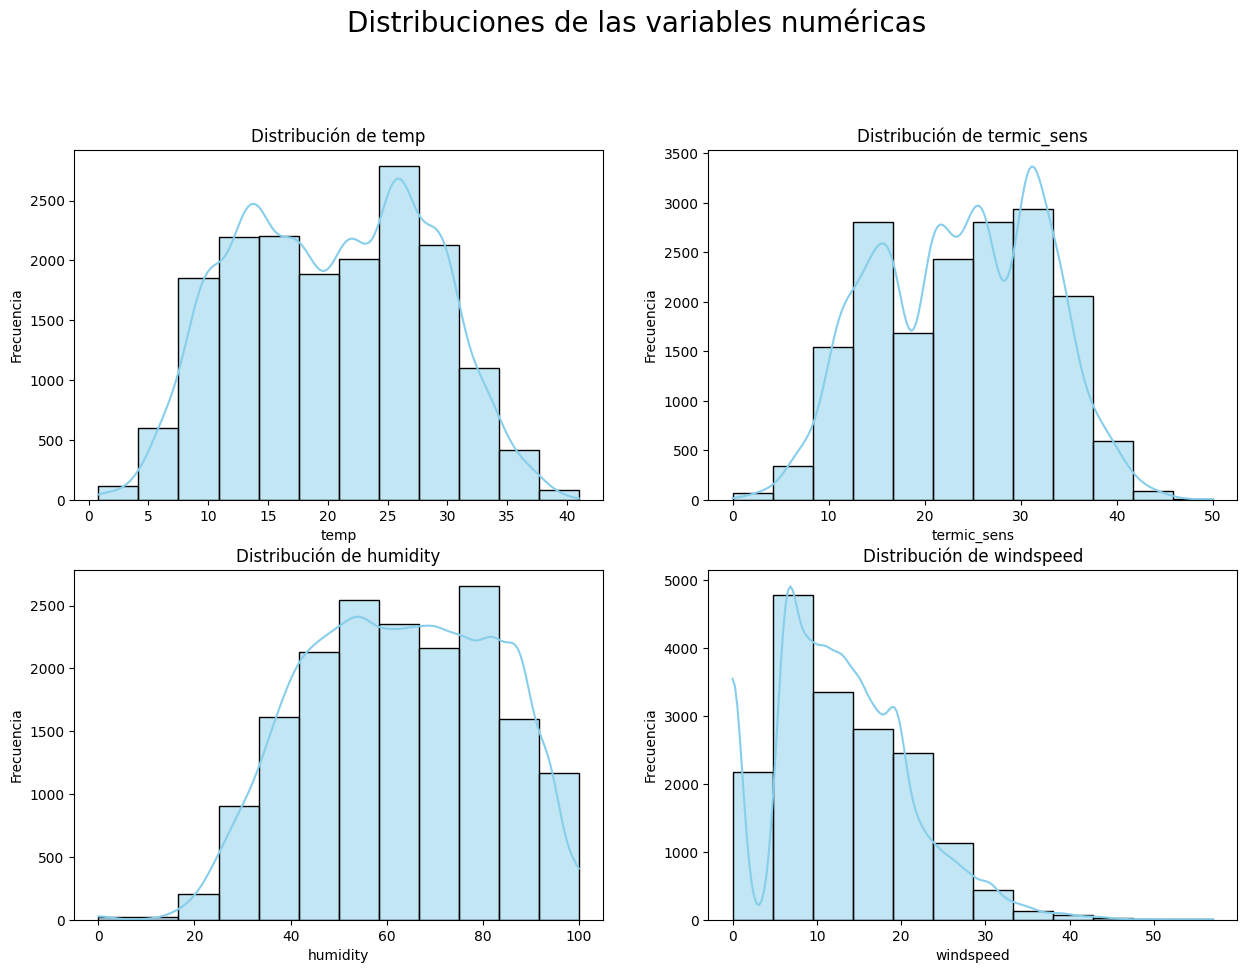

In [ ]:
# @title
# Graficar las distribuciones de las variable numericas
plt.figure(figsize=(15, 10))
plt.suptitle('Distribuciones de las variables numéricas', fontsize=20, y=1.02)
pvariables_pred = ['temp', 'termic_sens', 'humidity', 'windspeed']
for i, col in enumerate( pvariables_pred, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], bins=12, kde=True, color='skyblue')
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')


Vemos que las variables siguen una distribución aproximadamente normal.   
Con algunos valores un poco más sesgados para la velocidad del viento.

<font color="white">.</font>
### Vemos si hay valores atípicos (outliers) en las posibles variables predictoras

In [ ]:
IQR = df["windspeed"].quantile(0.75) - df["windspeed"].quantile(0.25)
upper_bound = df["windspeed"].quantile(0.75) + (1.5 * IQR)
#outliers = [df[(df["windspeed"] > upper_bound)]
print(f"Outliers en la variable 'windspeed': valores > {upper_bound:.02f} ")


Outliers en la variable 'windspeed': valores > 31.99 


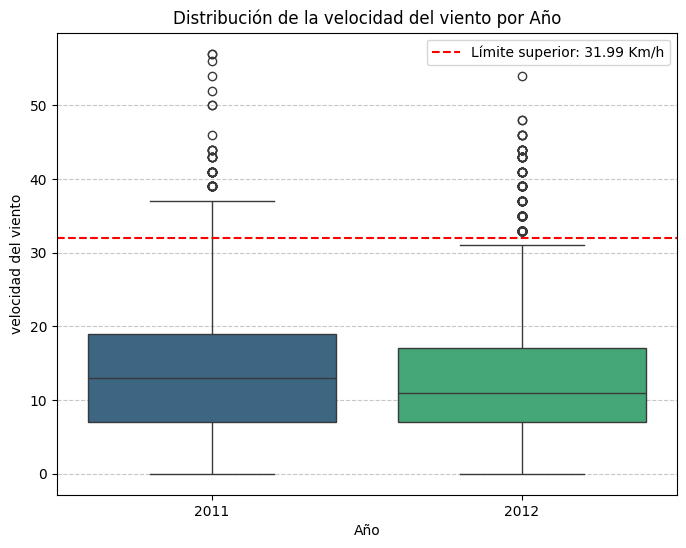

In [ ]:
# @title
# Distribución de la velocidad del viento
plt.figure(figsize=(8, 6))
sns.boxplot(x='year', y='windspeed', data=df.replace({'year': {0: 2011, 1: 2012}}), palette='viridis')
plt.title('Distribución de la velocidad del viento por Año')
plt.xlabel('Año')
plt.ylabel('velocidad del viento')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Añadir una línea horizontal para el upper_bound
plt.axhline(y=upper_bound, color='red', linestyle='--', label=f'Límite superior: {upper_bound:.2f} Km/h')
plt.legend()

plt.show()


En el gráfico de arriba vemos como la variable `windspeed` presenta outliers para valores mayores a (IQR * 1.5)   
Donde IQR es el **Rango Intercuartílico**   
Pero esos valores de viento son valores bastantes normales de viento.   
Por arriba de 50 km/h sólo hay 5 eventos, en más de 17000 registros.   
Son muy pocos, lo que confirma que son eventos raros pero legítimos y no se van a descartar.

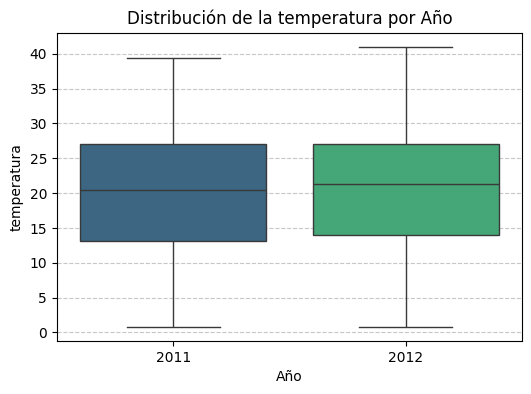

In [ ]:
# @title
# Distribución de la temperatura
plt.figure(figsize=(6, 4))
sns.boxplot(x='year', y='temp', data=df.replace({'year': {0: 2011, 1: 2012}}), palette='viridis')
plt.title('Distribución de la temperatura por Año')
plt.xlabel('Año')
plt.ylabel('temperatura')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

No hay outliers en la variable `temp` (temperatura), está en los rangos normales esperables

### Funciones auxiliares para trabajar

In [ ]:
# DayOfWeek()
def DOW( nday):
    aDays =["Domingo","Lunes", "Martes", "Miercoles","Jueves","Viernes","Sabado"]
    return aDays[ nday]

# working days goes from 1-5. 0=Domingo, 6=Sabado (no laborable)
# Numeric DOW() 0=Domingo .. 6=Sabado
def NDOW( fecha):
    if type(fecha) == str:
       fecha = pd.to_datetime(fecha)
    # Move the assignment of ndia outside the if block
    ndia = int(fecha.strftime("%w"))
    return ndia

In [ ]:
#  Estaciones en el Hemisferio Norte
season_list = ["","invierno","primavera", "verano", "otoño"]

def season( x):
    return season_list[x]

def get_season( fecha):
    ''' obtiene la estacion segun la fecha
    '''
    if type(fecha) == str:
        fecha = pd.to_datetime(fecha)

    dia = fecha.day
    mes = fecha.month

    if mes == 1 or mes == 2:
       nSeason = 1

    elif mes == 3:
       if dia < 21:
          nSeason = 1
       else:
          nSeason = 2
    elif mes == 4 or mes == 5:
        nSeason = 2

    elif mes == 6:
        if dia < 21:
           nSeason = 2
        else:
           nSeason = 3
    elif mes == 7 or mes == 8:
        nSeason = 3

    elif mes == 9:
        if dia < 21:
           nSeason = 3
        else:
           nSeason = 4
    elif mes == 10 or mes == 11:
        nSeason = 4

    elif mes == 12:
        if dia < 21:
           nSeason = 4
        else:
           nSeason = 1
    return nSeason

In [ ]:
# CLIMA: Vamos a resumir, conservando la idea:
clima_list = ["",
"Claro",
"Nublado / Niebla",
"LLuvia ligera/ Nevada ligera",
"Tormenta"]


## 3. Preprocesamiento y Preparación de los datos

Vamos a proceder a crear distintas columnas con el fin de poder hacer un analisis más granular y detallado<br> con respecto a los días de alquiler.

* Que día de la semana se hizo el alquiler ?   
  Creamos una columna con esa información => weekday

* El alquiler se hizo en un día laborable ?   
  Creamos una columna con esa información => workingday  

* El alquiler se hizo en un día feriado   
  Ya posee una columna con esa información => feriado

* El alquiler se hizo en un fin de semana ?    
  Creamos una columna con esa información => weekend
  (aunque en realidad esta implicito en !workingday)

* Los alquileres aumentan con el buen tiempo y por tanto de la estación del año
  en que se encuentre.   
  Creamos una columna con esa información => season


In [ ]:
# Creamos una columna con el nro dia de semana Dom =0 .. Sab =6
df["weekday"] = df["rental_date"].apply(NDOW)

In [ ]:
# Creamos una columna con esta información => workingday
# Si feriado es 1, workingday debe ser 0. De lo contrario,
# se calcula en función del día de la semana.
df["workingday"] = np.where(df["feriado"] == 1, 0,
                            df["weekday"].apply(lambda x: 1 if (x > 0 and x <6) else 0))

In [ ]:
# Creamos una columna con esa información => season
df["season"] = df["rental_date"].apply(get_season)

Reordenamos las columnas

In [ ]:
# Reordenamos las columnas
df = df[["rental_date", "hour", "year", "month", "weekday", "workingday", "feriado",
        "season", "temp", "termic_sens", "humidity", "windspeed", "clima",
        "casual_usr",	"regist_usr",	"count"]]


In [ ]:
df.head()

,rental_date,hour,year,month,weekday,workingday,feriado,season,temp,termic_sens,humidity,windspeed,clima,casual_usr,regist_usr,count
0,2011-01-01,0,0,1,6,0,0,1,9.84,14.395,81.0,0.0,1,3,13,16
1,2011-01-01,1,0,1,6,0,0,1,9.02,13.635,80.0,0.0,1,8,32,40
2,2011-01-01,2,0,1,6,0,0,1,9.02,13.635,80.0,0.0,1,5,27,32
3,2011-01-01,3,0,1,6,0,0,1,9.84,14.395,75.0,0.0,1,3,10,13
4,2011-01-01,4,0,1,6,0,0,1,9.84,14.395,75.0,0.0,1,0,1,1


### NORMALIZACIÓN
Normalizamos algunas variables numéricas, preparándolas para el modelo:  
El nombre de los campos va a estar precedido por "<font color="darkred">N</font>" indicando que estan normalizados

In [ ]:
# @title
df['humidity'].describe()

,humidity
count,17379.000000
mean,62.722884
std,19.292983
min,0.000000
25%,48.000000
50%,63.000000
75%,78.000000
max,100.000000


In [ ]:
# Se normaliza la humedad
# Los valores se dividen por 100 (max) porque tenemos un min =0
df['Nhumidity'] = df['humidity'] / 100

In [ ]:
# @title
df['windspeed'].describe()

In [ ]:
# Se normaliza el viento
# Los valores se dividen por 57 (max) porque tenemos un min =0
df['Nwindspeed'] = df['windspeed'] / 57

In [ ]:
# @title
df["temp"].describe()

In [ ]:
# Se normaliza la temperatura
# Creamos el escalador y aplicamos Min-Max Scaling para normalizar a un rango de [0, 1]
scaler_temp = MinMaxScaler()
df['Ntemp'] = scaler_temp.fit_transform(df[['temp']])

In [ ]:
# @title
df["termic_sens"].describe()

In [ ]:
# Se normaliza la sens termica dividiendo / 50
# Los valores se dividen por 50 (max) porque tenemos un min =0
df["Ntermic_sens"] = df["termic_sens"] / 50

In [ ]:
pd.set_option('display.max_columns', None)

.

## Normalizar 'clima' (usando One-Hot Encoding)

La columna 'clima' es una característica categórica.    
Para usarla efectivamente en un modelo de regresión lineal, necesitamos <br>convertirla a un formato numérico usando "one-hot encoding".    
Esto crea nuevas columnas binarias para cada categoria de 'clima'.

In [ ]:
# Hacemos una copia de df por las dudas
df_copy = df.copy()

In [ ]:
# @title
# restauro para reiniciar desde este punto
#df = df_copy.copy()

In [ ]:
# Normalizar 'clima' con One-Hot Encoding
one_hot_encoder = OneHotEncoder(sparse_output=False, dtype=int)
clima_encoded = one_hot_encoder.fit_transform(df[['clima']])

# Crea un DataFrame con las caracteristicas codificadas
clima_df = pd.DataFrame(clima_encoded, columns=one_hot_encoder.get_feature_names_out(['clima']))

# Eliminar la columna 'clima_4' para evitar multicolinearidad
clima_df = clima_df.drop(columns=['clima_4'])

# Concatenar las caracteristicas de 'clima' al DataFrame original df

# -- IMPORTANTE --
# Hay que elimir la columna 'clima' original de df para evitar errores
#
df = pd.concat([df, clima_df], axis=1)
# BORRARLA luego de la matriz de correlación


In [ ]:
# Normalizar 'season' con One-Hot Encoding
OHE = OneHotEncoder(sparse_output=False, dtype=int, drop='first')
season_encoded = OHE.fit_transform(df[['season']])
season_df = pd.DataFrame(season_encoded, columns=OHE.get_feature_names_out(['season']))
df = pd.concat([df, season_df], axis=1)


In [ ]:
# Mostramos el DF con nuevas cols de 'clima_' y 'season_'
df.head()

,rental_date,hour,year,month,weekday,workingday,feriado,season,temp,termic_sens,...,Nhumidity,Nwindspeed,Ntemp,Ntermic_sens,clima_1,clima_2,clima_3,season_2,season_3,season_4
0,2011-01-01,0,0,1,6,0,0,1,9.84,14.395,...,0.81,0.0,0.224490,0.2879,1,0,0,0,0,0
1,2011-01-01,1,0,1,6,0,0,1,9.02,13.635,...,0.80,0.0,0.204082,0.2727,1,0,0,0,0,0
2,2011-01-01,2,0,1,6,0,0,1,9.02,13.635,...,0.80,0.0,0.204082,0.2727,1,0,0,0,0,0
3,2011-01-01,3,0,1,6,0,0,1,9.84,14.395,...,0.75,0.0,0.224490,0.2879,1,0,0,0,0,0
4,2011-01-01,4,0,1,6,0,0,1,9.84,14.395,...,0.75,0.0,0.224490,0.2879,1,0,0,0,0,0


In [ ]:
df.info()

## Preparamos algunos datos para poder graficar la información.   
Y de esta forma, tener una mejor idea de lo que vamos a intentar predecir

In [ ]:
# cantidad de registros de 2011
reg_2011 = df[df["year"] == 0].shape[0]
print(f"reg 2011: {reg_2011} registros")

reg 2011: 8645 registros


In [ ]:
# cantidad de registros de 2012
reg_2012 = df[df["year"] == 1].shape[0]
print(f"reg 2012: {reg_2012} registros")

print(f"Total reg 2011-2012: {reg_2011 + reg_2012} registros" )

reg 2012: 8734 registros
Total reg 2011-2012: 17379 registros


In [ ]:
# agregado por mes y año
total_mes = df.groupby(['year', 'month'])['count'].sum().reset_index()
total_mes['year'] = total_mes['year'].map({0: 2011, 1: 2012})

# agregado total por año
total_year = df.groupby(['year'])['count'].sum().reset_index()
total_year['year'] = total_year['year'].map({0: 2011, 1: 2012})

In [ ]:
total_mes

,year,month,count
0,2011,1,38189
1,2011,2,48215
2,2011,3,64045
3,2011,4,94870
4,2011,5,135821
5,2011,6,143512
6,2011,7,141341
7,2011,8,136691
8,2011,9,127418
9,2011,10,123511


In [ ]:
display(total_year)

# Obtenemos los totales por año
y2011 = total_year.iloc[0,1]
y2012 = total_year.iloc[1,1]


,year,count
0,2011,1243103
1,2012,2049576


In [ ]:
delta = (y2012 *100 /y2011) -100
print(f"Incremento en el alquiler: { delta:.02f} % más")

Incremento en el alquiler: 64.88 % más


In [ ]:
# calculo de la temp media del año 2011
df_2011 = df[df["year"] == 0]
temp_media_2011 = df_2011["temp"].mean()
print(f"{temp_media_2011:.02f}")

# calculo de la temp media del año 2012
df_2012 = df[df["year"] == 1]
temp_media_2012 = df_2012["temp"].mean()
print(f"{temp_media_2012:.02f}")

20.05
20.70


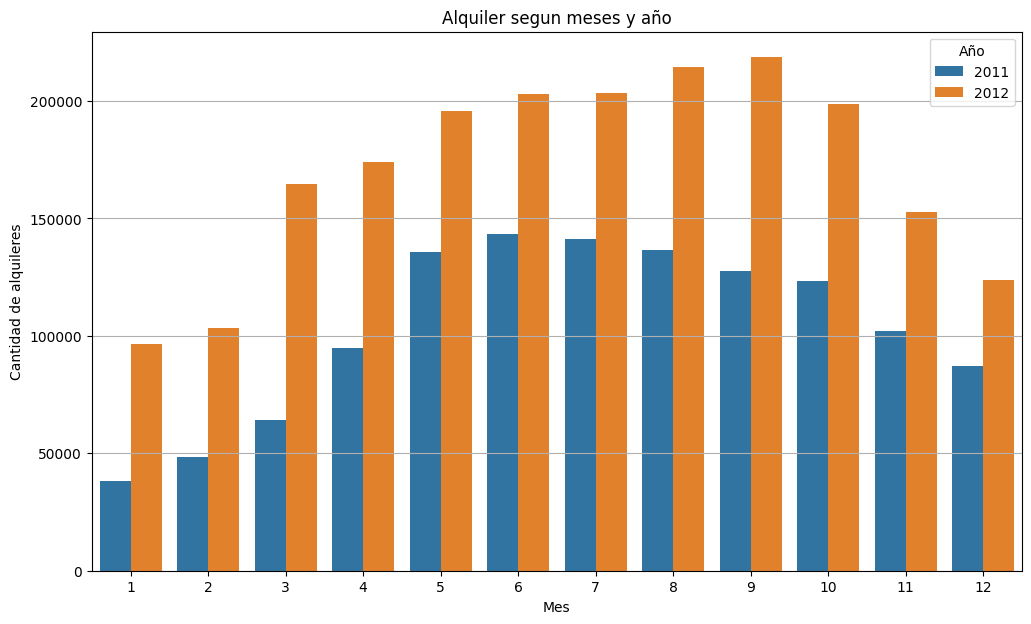

In [ ]:
# @title
plt.figure(figsize=(12, 7))
sns.barplot(x='month', y='count', hue='year', data=total_mes, palette='tab10')
plt.title('Alquiler segun meses y año')
plt.xlabel('Mes')
plt.ylabel('Cantidad de alquileres')
plt.xticks(rotation=0)
plt.legend(title='Año')
plt.grid(axis='y')
plt.show()

In [ ]:
# agregado por season y año
total_season = df.groupby(['year', 'season'])['count'].sum().reset_index()
total_season['year'] = total_season['year'].map({0: 2011, 1: 2012})

In [ ]:
total_season['season_name'] = total_season['season'].apply(season)

In [ ]:
display(total_season)

,year,season,count,season_name
0,2011,1,150000,invierno
1,2011,2,347316,primavera
2,2011,3,410503,verano
3,2011,4,335284,otoño
4,2012,1,321348,invierno
5,2012,2,571273,primavera
6,2012,3,624917,verano
7,2012,4,532038,otoño


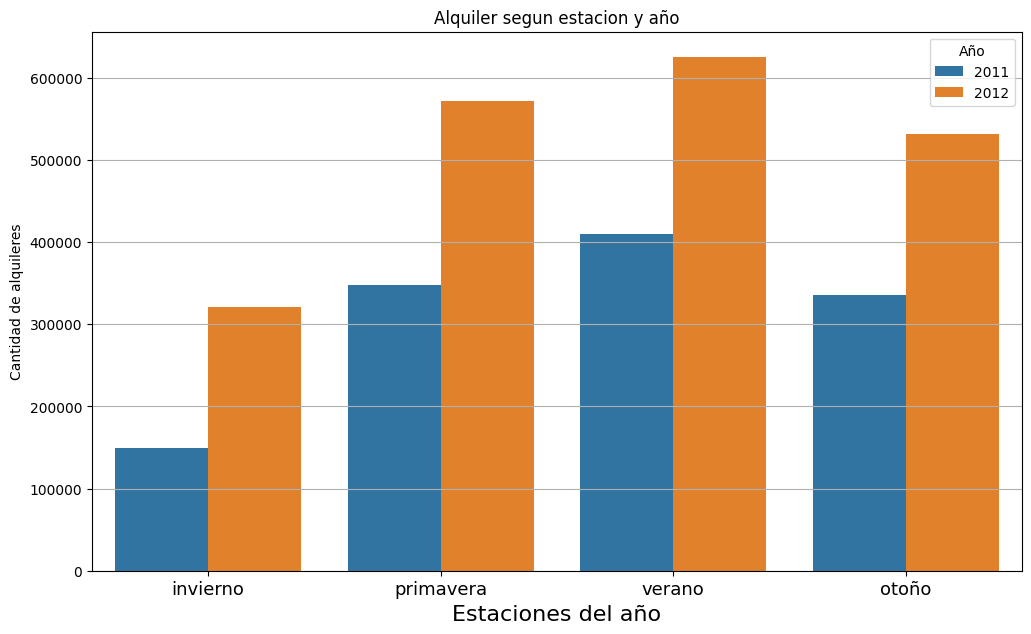

In [ ]:
# @title
plt.figure(figsize=(12, 7))
sns.barplot(x='season_name', y='count', hue='year', data=total_season, palette='tab10')
plt.title('Alquiler segun estacion y año')
plt.xlabel('Estaciones del año', size="16")
plt.ylabel('Cantidad de alquileres')
plt.xticks(rotation=0, size=13)
plt.legend(title='Año')
plt.grid(axis='y')
plt.show()

In [ ]:
# agregado por hora, season y año
mean_hour = df.groupby(['year', 'season', 'hour'])['count'].mean().reset_index()
mean_hour['year'] = mean_hour['year'].map({0: 2011, 1: 2012})


In [ ]:
# Redondeamos el valor de 'count' en mean_hour
mean_hour['count'] = mean_hour['count'].apply(lambda x: round(x))
mean_hour

,year,season,hour,count
0,2011,1,0,19
1,2011,1,1,12
2,2011,1,2,8
3,2011,1,3,5
4,2011,1,4,2
...,...,...,...,...
187,2012,4,19,366
188,2012,4,20,261
189,2012,4,21,195
190,2012,4,22,148


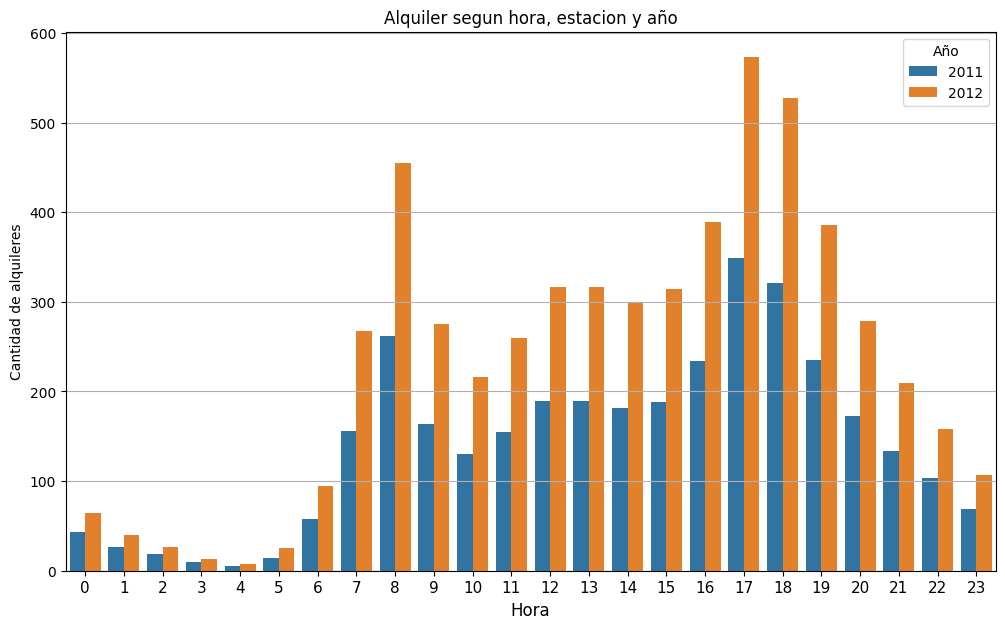

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='hour', y='count', hue='year', data=mean_hour, palette='tab10', errorbar=None)
plt.title('Alquiler segun hora, estacion y año')
plt.xlabel('Hora', size="12")
plt.ylabel('Cantidad de alquileres')
plt.xticks(rotation=0, size=11)
plt.legend(title='Año')
plt.grid(axis='y')
plt.show()

<font color="white">que significa la barra superior en cada hora del grafico<br>
La barra superior en cada hora del gráfico se conoce como barra de error. Dado que el gráfico muestra el promedio de alquileres por hora, esta barra de error representa el intervalo de confianza de la media. <br><br>
En este caso, una barra más larga indica una mayor variabilidad en la cantidad de alquileres de bicicletas para esa hora en particular, lo que significa que el número de alquileres puede fluctuar mucho alrededor del promedio. Una barra más corta sugiere que los alquileres son más consistentes con el promedio para esa hora. Por defecto, Seaborn usa un intervalo de confianza del 95%. </font>

## Matriz de Correlación

Vamos a generar una matriz de correlación para entender las relaciones entre las variables numéricas del dataset.    
Esto nos ayudará a identificar qué variables están fuertemente relacionadas entre sí o con la **variable objetivo** <font color="red">`count`</font>.

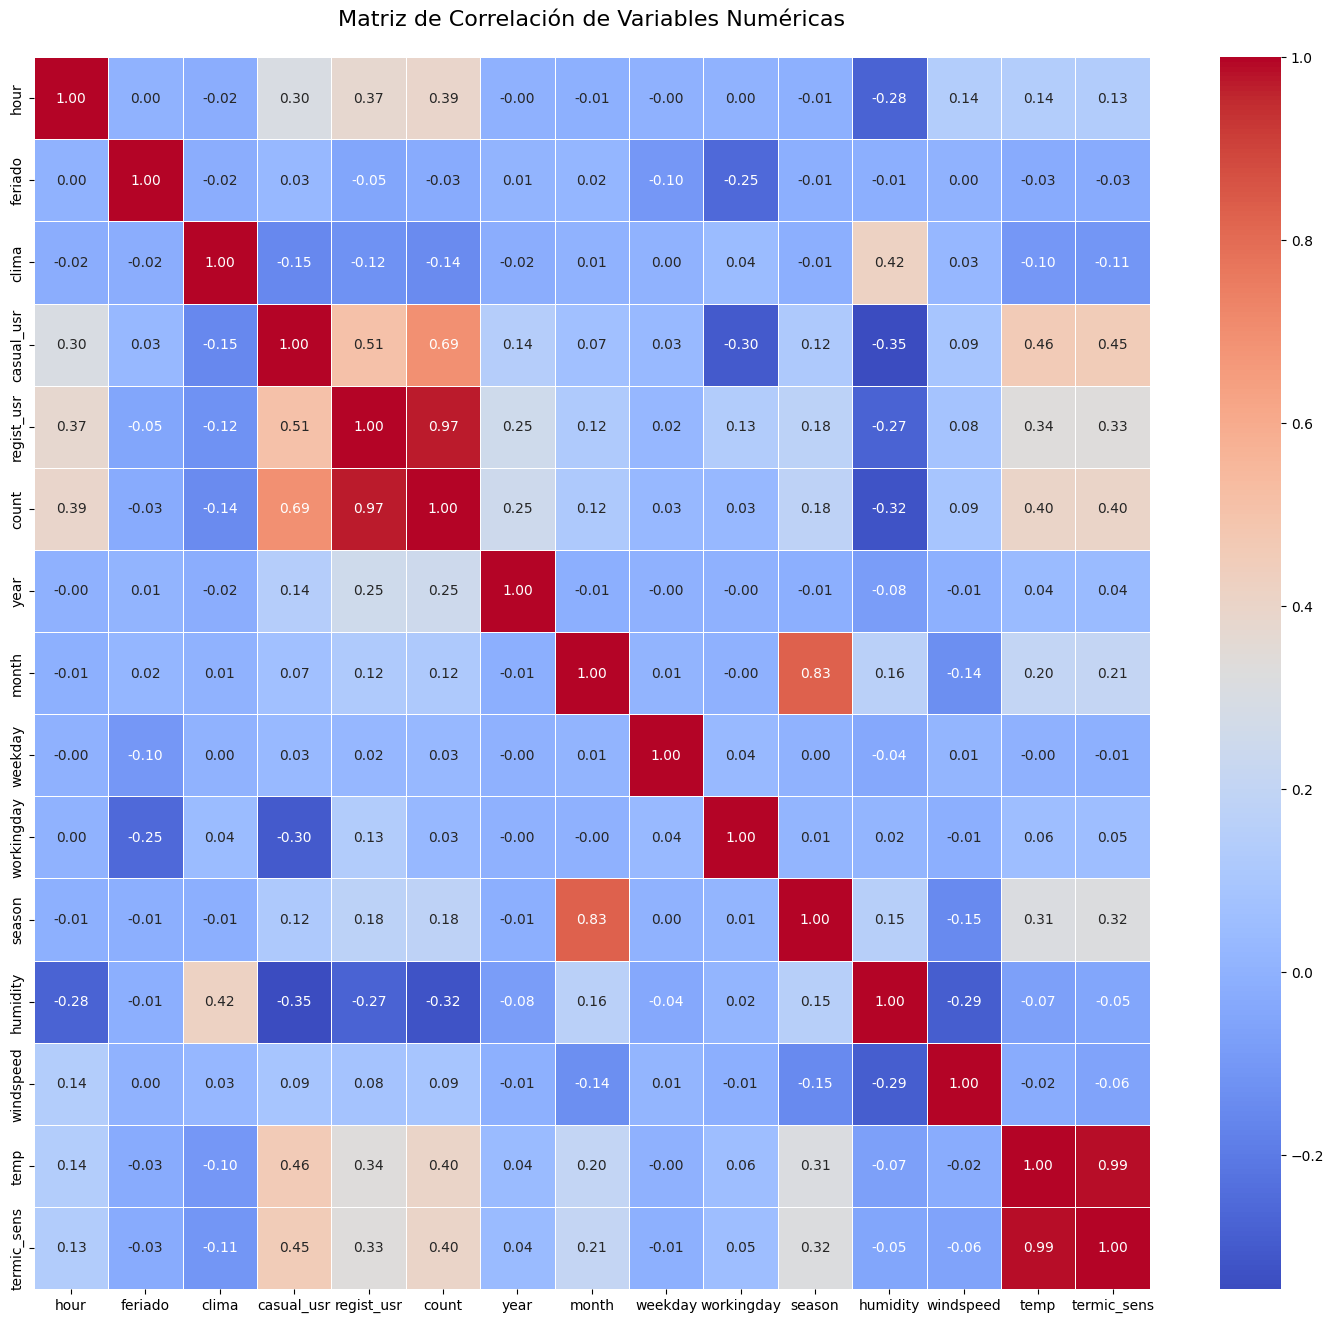

In [ ]:
# @title
#import seaborn as sns
#import matplotlib.pyplot as plt

# Seleccionamos las columnas numéricas relevantes para la matriz de correlación
numerical_cols = [
    'hour', 'feriado', 'clima', 'casual_usr', 'regist_usr', 'count',
    'year', 'month', 'weekday', 'workingday', 'season',
    'humidity', 'windspeed', 'temp', 'termic_sens'
]

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(18, 16))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlación de Variables Numéricas\n', size=16)
plt.show()

Como podemos ver en el mapa de calor:   
* usarios registrados tienen correlación alta con la cantidad de alquileres (0.97)
* usuarios casuales tienen correlación media con la cantidad de alquileres (0.69)

<font color="darkred">Por dicho motivo deberemos sacar estas variables de la lista de variables predictoras.  
Porque de lo contrario, sería como si el modelo viera el resultado.

Ahora debemos ver cómo afectan el clima (humedad / lluvia / nieve, temp, viento), consecuencia de season (estación del año) y la hora del día en los alquileres.

La humedad, `humidity` y la velocidad del viento, `windspeed`, tienen una baja correlación con `count`, la variable objetivo.   
La `temp` y la `termic_sens` tienen una correlación media con `count`.   

Las variables `month`, `feriado`, `weekday`, `workingday`, `season` tienen una baja correlación con  `count`

In [ ]:
c4 = df[df["clima"] == 4]
print(f"Cantidad de alquileres con clima = 4 ({clima_list[4]}): {c4.shape[0]}")
c4

Cantidad de alquileres con clima = 4 (Tormenta): 3


,rental_date,hour,year,month,weekday,workingday,feriado,season,temp,termic_sens,humidity,windspeed,clima,casual_usr,regist_usr,count,Nhumidity,Nwindspeed,Ntemp,Ntermic_sens,clima_1,clima_2,clima_3,season_2,season_3,season_4
585,2011-01-26,16,0,1,3,1,0,1,9.02,9.850,93.0,22.0028,4,1,35,36,0.93,0.386014,0.204082,0.1970,0,0,0,0,0,0
8854,2012-01-09,18,1,1,1,1,0,1,8.20,11.365,86.0,6.0032,4,6,158,164,0.86,0.105319,0.183673,0.2273,0,0,0,0,0,0
9123,2012-01-21,1,1,1,6,0,0,1,5.74,6.820,86.0,12.9980,4,1,22,23,0.86,0.228035,0.122449,0.1364,0,0,0,0,0,0


##Gráficos para establecer una mejor relación entre las variables

<Figure size 500x500 with 0 Axes>

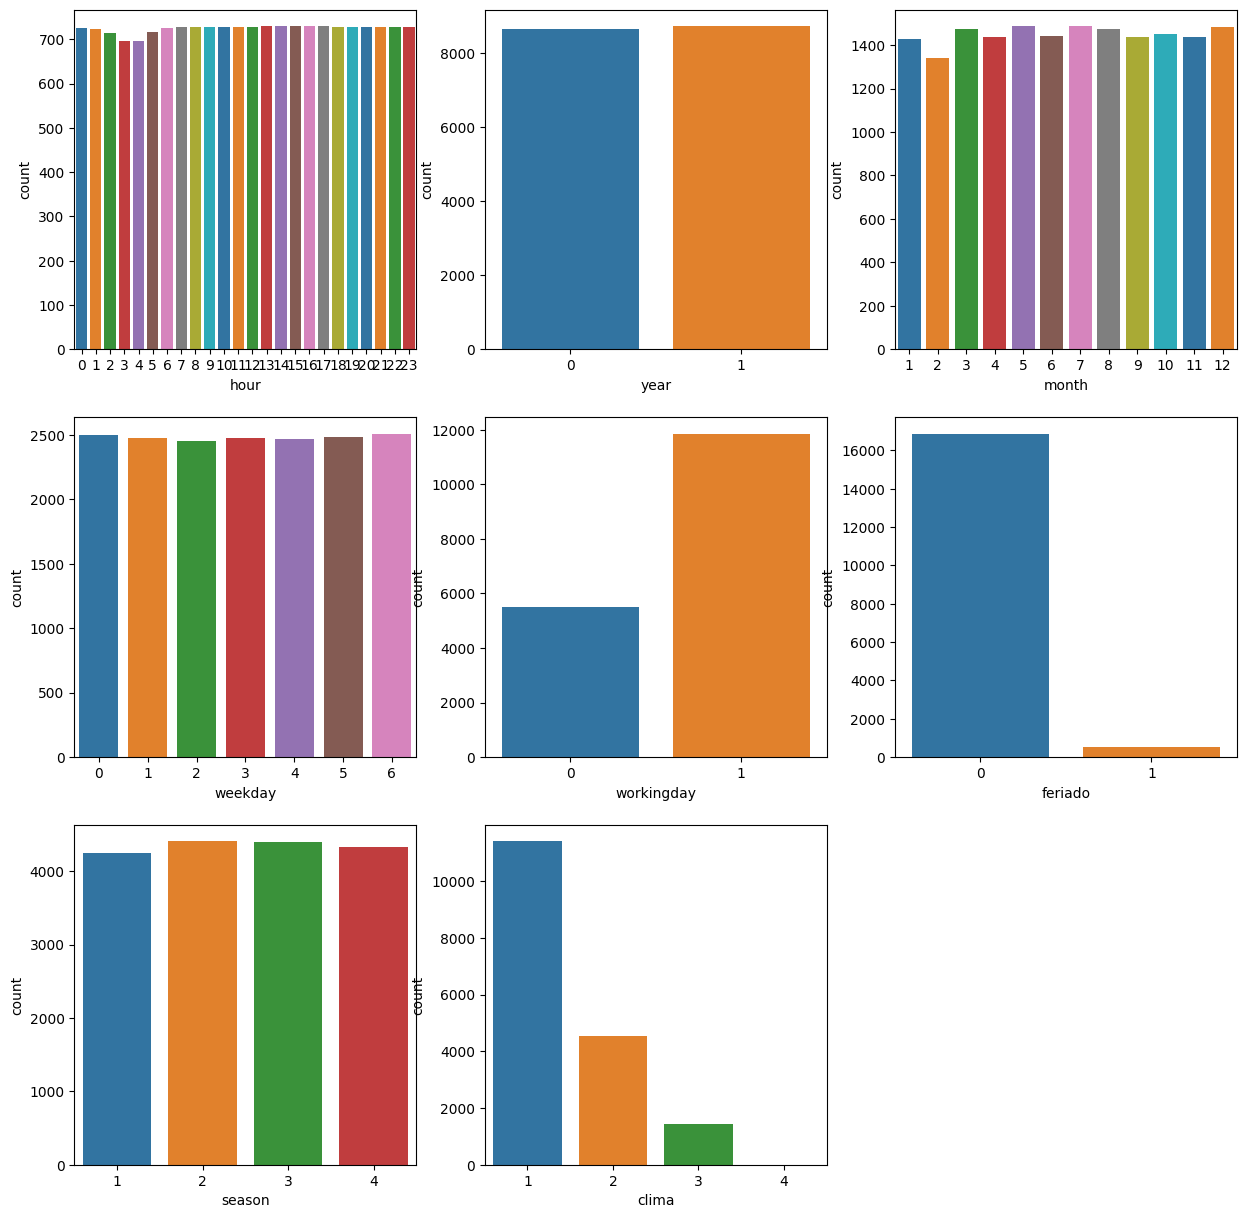

In [ ]:
# Contar valores para cada columna que tiene valores contables y graficar esta
# cantidad como "count"

#plt.style.use('ggplot')
plt.figure(figsize=(5,5))
counter=1
plt.figure(figsize=(15,15))

for col in df.columns:
    if col in ['season','year','month', 'hour','feriado', 'clima','weekday','workingday']:

        #print(f"\nthe column {col} has: ",df[col].value_counts())
        plt.subplot(3,3,counter)
        sns.countplot(x=col,data=df, palette='tab10' )
        counter+=1
plt.show()


#### De los gráficos de arriba podemos extraer conclusiones:   
<font color="green">Se renta mayor cantidad: </font>  
* si el dia es laborable (workingday=1)
* si el dia NO es feriado (feriado=0)
* Si hay buenas condiciones meteorologicas(clima=1)  

<font color="darkred">Se renta menor cantidad: </font>
* Disminuye un poco en las primeras horas de la madrugada
* Disminuye un poco en el mes de Febrero (invierno)

Donde el CLIMA es:
1. Cielo claro o parcialmente nublado   
2. Con niebla / nublado
3. Con lluvia ligera / nieve ligera
4. Con Lluvia Intensa / Granizo / Tormenta + Niebla / Nieve + Niebla   

**Hay sólo 3 alquileres cuando el clima == 4 (tormenta)**    
<br>


In [ ]:
# Dividimos datos en numerical y categorical features

categorical_features = df[["month", "season", "feriado", "clima"]].astype("category").copy()

numerical_features = df.select_dtypes(exclude = 'object')


In [ ]:
categorical_features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17379 entries, 0 to 17378
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   month    17379 non-null  category
 1   season   17379 non-null  category
 2   feriado  17379 non-null  category
 3   clima    17379 non-null  category
dtypes: category(4)
memory usage: 204.5 KB


In [ ]:
categorical_features.head()

,month,season,feriado,clima
0,1,1,0,1
1,1,1,0,1
2,1,1,0,1
3,1,1,0,1
4,1,1,0,1


In [ ]:
numerical_features.head(2)

,rental_date,hour,year,month,weekday,workingday,feriado,season,temp,termic_sens,...,Nhumidity,Nwindspeed,Ntemp,Ntermic_sens,clima_1,clima_2,clima_3,season_2,season_3,season_4
0,2011-01-01,0,0,1,6,0,0,1,9.84,14.395,...,0.81,0.0,0.224490,0.2879,1,0,0,0,0,0
1,2011-01-01,1,0,1,6,0,0,1,9.02,13.635,...,0.80,0.0,0.204082,0.2727,1,0,0,0,0,0


In [ ]:
df.info()

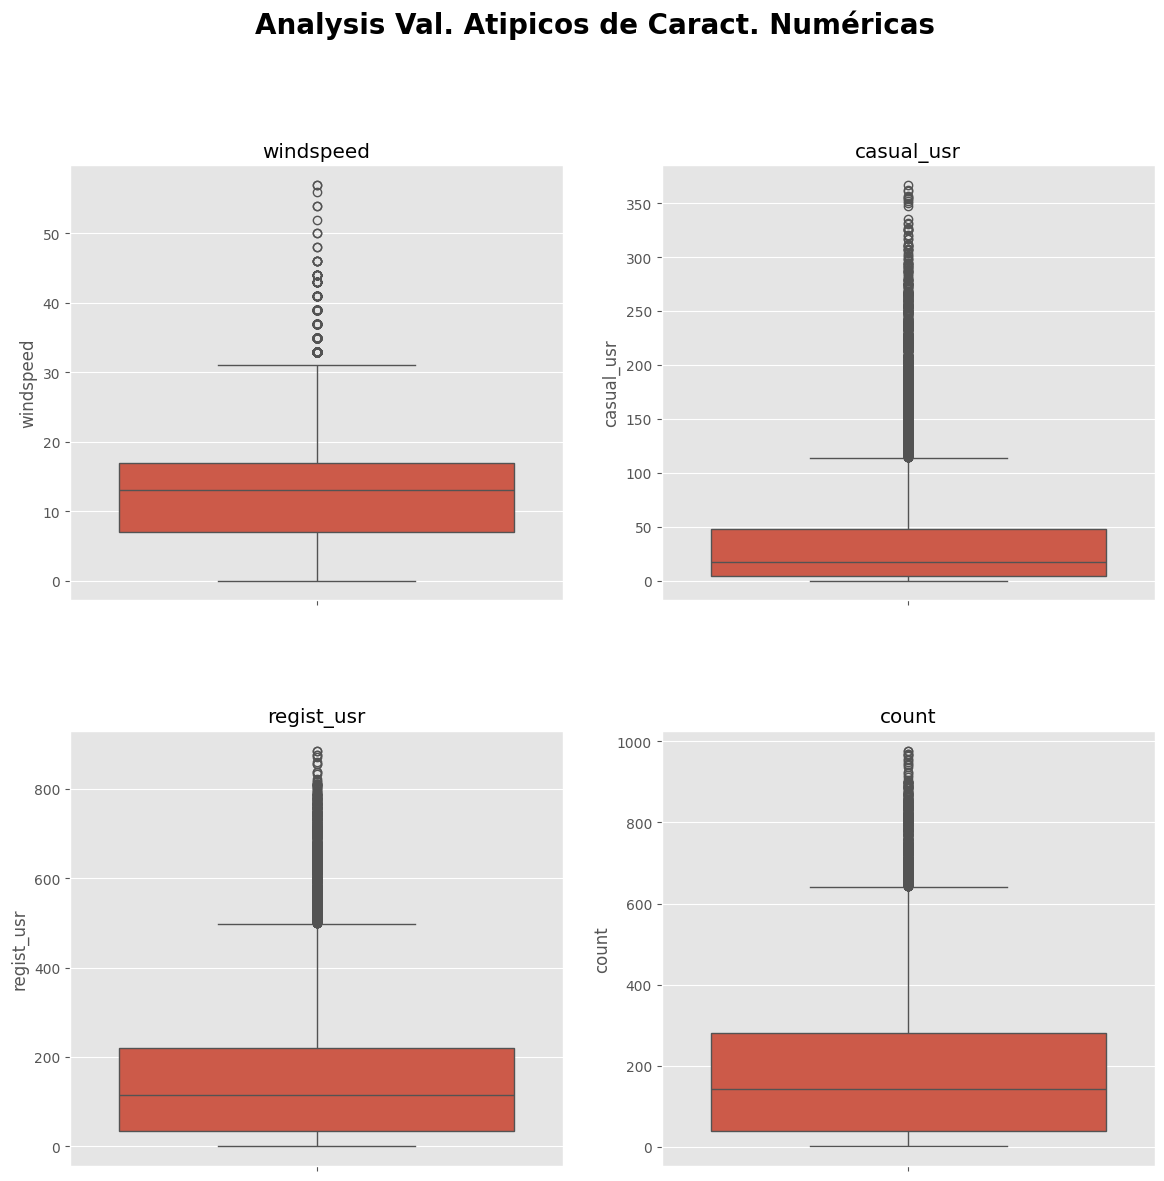

In [ ]:
# @title
plt.style.use('ggplot')
# Definimos caract numericas continuas para analisis de los outliers
numerical_feat_4bp = [ 'windspeed', 'casual_usr', 'regist_usr', 'count']

# Ajustamos figsize
plt.figure(figsize=(14, 13))
plt.suptitle('Analysis Val. Atipicos de Caract. Numéricas', fontsize=20, fontweight='bold', y=1.0)

n_features = len(numerical_feat_4bp)
n_cols_plot = 2

# Calculamos numero de filas dinamicamente. Donde "//" es divisor de piso
n_rows_plot = (n_features + n_cols_plot - 1) // n_cols_plot

for i, col in enumerate(numerical_feat_4bp):
    plt.subplot(n_rows_plot, n_cols_plot, i + 1)
    sns.boxplot(df[col])
    plt.title(col)

# Ajustamos espaciado vertical
plt.subplots_adjust(hspace=0.3)
plt.show()


Como vemos en los boxplot, por los outliers se da un crecimiento exagerado de la variable objetivo `count`,    
muy probablemente, explicado por el gran aumento en los usuarios casuales y registrados

## Analizar demanda de bicicletas con respecto a "hour" y otra variable


In [ ]:
# @title
from re import sub
# Analizar demanda de bicicletas con respecto a "hour" y otra variable

# Definir mapeos para caracteristicas categoricas de etiquetas
month_names = {
    1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril',
    5: 'Mayo', 6: 'Junio', 7: 'Julio', 8: 'Agosto',
    9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'
}
season_labels = {
    1: 'Invierno', 2: 'Primavera', 3: 'Verano', 4: 'Otoño'
}
feriado_labels = {
    0: 'No Feriado', 1: 'Feriado'
}
clima_labels = {
    1: 'Claro', 2: 'Niebla/Nublado', 3: 'Nieve/Lluvia Ligera', 4: 'Tormenta'
}

for i in categorical_features:
  #print(i)

  if i == 'hour':
    pass
  else:
    #plt.figure(figsize=(15,8))
    fig, ax = plt.subplots(figsize=(15, 8))

    temp_hue_col_name = i +"_labels"
    if i == 'month':
       df[temp_hue_col_name] = df[i].map(month_names)
       #print(df[temp_hue_col_name])
    elif i == 'season':
       df[temp_hue_col_name] = df[i].map(season_labels)
    elif i == 'feriado':
       df[temp_hue_col_name] = df[i].map(feriado_labels)
    elif i == 'clima':
       df[temp_hue_col_name] = df[i].map(clima_labels)
    else:
       # Fallback for any other unexpected categorical feature
       df[temp_hue_col_name] = df[i]

    sns.lineplot(x= df["hour"], y= df['count'], hue=df[temp_hue_col_name], ax=ax,
                 marker ='o', palette="deep")
    plt.title(f"\n\nDemanda bicicletas por Hora respecto de {i}", size=16)
    ax.set_xticks(range(0, 24, 1))
    plt.xlabel("Hora", size=12)
    plt.ylabel("Cantidad")
    ax.set_xlim(0, 23)
    plt.show()


En los gráficos vemos que hay una gran consistente demanda:
* entre  7-9 hs. => horario de entrada al trabajo, escuelas, colegios...    
* entre 16-19.30 => horario de salida del trabajo, escuelas, colegios...

In [ ]:
# eliminar las columnas agregadas _labels para etiquetar los graficos
df = df.drop(columns=['month_labels','season_labels', 'feriado_labels','clima_labels'])


In [ ]:
df.info()


#PARTE II (Entrega)

## Separación de variable objetivo y variables predictoras

## Selección de Características para el Modelo Predictivo

Ahora que hemos explorado y preprocesado los datos, seleccionaremos las características que utilizaremos para entrenar nuestro modelo predictivo. La variable objetivo es <font color="red">`count`</font> (cantidad total de alquileres por hora).

Eliminaremos las columnas originales de temperatura, humedad, velocidad del viento y clima, ya que tenemos sus versiones normalizadas (`Ntemp`, `Ntermic_sens`, `Nhumidity`, `Nwindspeed`) o codificadas (`clima_2`, `clima_3`, `clima_4`).    

 <font color="white">
 .
 </font>

 La eliminación de usuarios: `casual_usr` y `regist_usr` es porque son componentes de la variable objetivo `count`, y que su inclusión causaría una fuga de datos (data leakage) que podría resulta en un rendimiento del modelo engañosamente alto.    
 Pero por otro lado su no inclusión, margina 2 variables importantes de la predicción y perdería eficiencia la predicción.

Finalmente, `rental_date` también se eliminará porque ya hemos extraído `year`, `month`, y `weekday` de ella.

## Variable Objetivo:
En este dataset, la variable objetivo es <font color="red">`count`</font>, (cantidad de alquileres por hora), porque representa el valor que se intenta predecir.

Se intenta predecir el año siguiente (2012), solamente a partir de las variables predictoras del año 2011:  
<font color="darkgreen">
**hour, year, month, weekday, workingday, feriado, Ntemp, Ntermic_sens, Nhumidity, Nwindspeed,   
clima_1, clima_2, clima_3, season_2,season_3, season_4**</font>

<br>Descartamos las siguientes columnas:   
* **rental_date** (la fecha esta desglosada en year, month, day, weekday y hour)
* **temp, termic_sens, humidity, windspeed** (por sus equivalentes normalizadas)
* **casual_usr, regist_usr** (porque dan el resultado al modelo)

In [3]:
drop_columns = [
    'rental_date', 'temp', 'termic_sens', 'humidity', 'windspeed',
    'casual_usr', 'regist_usr', 'clima', 'season']

In [ ]:
# Descartamos las columnas innecesarias y/o perjudiciales
df = df.drop(columns=drop_columns)

In [ ]:
df.head()

,hour,year,month,weekday,workingday,feriado,count,Nhumidity,Nwindspeed,Ntemp,Ntermic_sens,clima_1,clima_2,clima_3,season_2,season_3,season_4
0,0,0,1,6,0,0,16,0.81,0.0,0.224490,0.2879,1,0,0,0,0,0
1,1,0,1,6,0,0,40,0.80,0.0,0.204082,0.2727,1,0,0,0,0,0
2,2,0,1,6,0,0,32,0.80,0.0,0.204082,0.2727,1,0,0,0,0,0
3,3,0,1,6,0,0,13,0.75,0.0,0.224490,0.2879,1,0,0,0,0,0
4,4,0,1,6,0,0,1,0.75,0.0,0.224490,0.2879,1,0,0,0,0,0


## División de Datos en Conjuntos de Entrenamiento y Prueba

Para evaluar el rendimiento de nuestro modelo de manera realista, dividiremos los datos:
- **Entrenamiento:** Utilizaremos los datos del año 2011.
- **Prueba:** Utilizaremos los datos del año 2012.

Esta estrategia de división es crucial para series de tiempo, ya que evita la fuga de datos del futuro al pasado y simula un escenario de predicción real, donde el modelo debe predecir eventos futuros basándose solo en información pasada.
El modelo usará patrones horarios, estacionales, etc del año 2011 para estimar la demanda del 2012, sin conocer explícitamente el año

In [ ]:
# Crea un DataFrame con solamente datos de 2011 para entrenamiento
df_2011 = df[df['year'] == 0].copy()

# Crea un DataFrame con solamente datos de 2012 para test / prueba
df_2012 = df[df['year'] == 1].copy()

In [ ]:
df_2011.info()

In [ ]:
df_2012.info()

In [ ]:
# guardar una copia de df_2011 (entrenamiento) y otra de df_2012 (test)
#df_2011.to_csv('df_2011_entr.csv', index=False)
#df_2012.to_csv('df_2012_test.csv', index=False)

In [5]:
# @title
# levantar archivos de entrenamiento y test
#df_2011 = pd.read_csv(ruta + 'df_2011_entr.csv')
#df_2012 = pd.read_csv(ruta + 'df_2012_test.csv')

Las variables estan separadas en:

- `X`: variables predictoras;
- `y`: variable objetivo.

In [6]:
# Dividir los datos para Entrenamiento (2011)

X_train = df_2011.drop(columns=['year','count'])
y_train = df_2011['count']

In [7]:
# datos de Entrenamiento
print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de y_train:", y_train.shape)
print("\nPrimeras 5 filas de X_train:")
display(X_train.head())

print("\nPrimeras 5 filas de y_train:")
display(y_train.head())

Dimensiones de X_train: (8645, 15)
Dimensiones de y_train: (8645,)

Primeras 5 filas de X_train:


,hour,month,weekday,workingday,feriado,Nhumidity,Nwindspeed,Ntemp,Ntermic_sens,clima_1,clima_2,clima_3,season_2,season_3,season_4
0,0,1,6,0,0,0.81,0.0,0.224490,0.2879,1,0,0,0,0,0
1,1,1,6,0,0,0.80,0.0,0.204082,0.2727,1,0,0,0,0,0
2,2,1,6,0,0,0.80,0.0,0.204082,0.2727,1,0,0,0,0,0
3,3,1,6,0,0,0.75,0.0,0.224490,0.2879,1,0,0,0,0,0
4,4,1,6,0,0,0.75,0.0,0.224490,0.2879,1,0,0,0,0,0



Primeras 5 filas de y_train:


,count
0,16
1,40
2,32
3,13
4,1


In [8]:
# Dividir los datos para Prueba (2012)

X_test = df_2012.drop(columns=['year','count'])
y_test = df_2012['count']

In [9]:
# datos de Prueba
print("Dimensiones de X_test:", X_test.shape)
print("Dimensiones de y_test:", y_test.shape)

Dimensiones de X_test: (8734, 15)
Dimensiones de y_test: (8734,)


## Entrenamiento del Modelo de Regresión Lineal

Elegimos este modelo por su simplicidad y como un buen punto de partida para establecer una base de rendimiento.   
El modelo aprenderá las relaciones entre las características de las variables predictoras en `X_train` y la variable objetivo `y_train`.

In [10]:
# Importar el modelo de regresión lineal
from sklearn.linear_model import LinearRegression

# Inicializar el modelo de regresión lineal
linear_model = LinearRegression()

# Entrenar el modelo con los datos de entrenamiento
linear_model.fit(X_train, y_train)

print("Modelo de Regresión Lineal entrenado con éxito.")

Modelo de Regresión Lineal entrenado con éxito.


In [11]:
# probar usando validacion cruzada
from sklearn.model_selection import KFold, cross_val_score

# Configurar la validación cruzada con KFold
# n_splits: número de 'folds' o divisiones (ej. 5)
# shuffle: mezclar los datos antes de dividir (importante para evitar sesgos
# temporales si los datos están ordenados)
# random_state: para reproducibilidad de los resultados
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Realizar la validación cruzada
# scoring: la métrica que queremos optimizar o evaluar (ej. 'r2' para R-squared)
cv_scores = cross_val_score(linear_model, X_train, y_train, cv=kf,
                            scoring='r2', n_jobs=-1)

print(f"Puntuaciones R2 de la validación cruzada: {cv_scores.round(2)}")
print(f"Media de R2 en validación cruzada: {cv_scores.mean():.2f}")
print(f"Desviación estándar de R2 en validación cruzada: {cv_scores.std():.2f}")

# También puedes evaluar otras métricas, por ejemplo MAE:
cv_mae_scores = cross_val_score(linear_model, X_train, y_train, cv=kf,
                                scoring='neg_mean_absolute_error', n_jobs=-1)
print(f"Media de MAE (negativo) en validación cruzada: {cv_mae_scores.mean():.2f}")
print(f"MAE promedio (valor positivo): {-cv_mae_scores.mean():.2f}")


Puntuaciones R2 de la validación cruzada: [0.41 0.41 0.39 0.4  0.37]
Media de R2 en validación cruzada: 0.40
Desviación estándar de R2 en validación cruzada: 0.01
Media de MAE (negativo) en validación cruzada: -78.84
MAE promedio (valor positivo): 78.84


## Evaluación del Modelo de Regresión Lineal

Una vez que el modelo ha sido entrenado, es crucial evaluar su rendimiento en el conjunto de prueba para determinar qué tan bien generaliza con datos no vistos. Utilizaremos las siguientes métricas:

*   **Mean Absolute Error (MAE)**: Es el promedio de las diferencias absolutas entre las predicciones y los valores reales. Es robusto a los valores atípicos y está en la misma unidad que la variable objetivo, lo que facilita su interpretación. <br>  
  
*   **Mean Squared Error (MSE)**: Es el promedio de los errores al cuadrado entre las predicciones y los valores reales. Penaliza más los errores grandes. Al estar al cuadrado, su unidad no es la misma que la variable objetivo.   

*   **Root Mean Squared Error (RMSE)**: Es la raíz cuadrada del MSE. Se interpreta en las mismas unidades que la variable objetivo y es útil para entender la magnitud típica del error. Es más sensible a los valores atípicos que el MAE.

*   **R-squared (R2)**: Representa la proporción de la varianza en la variable dependiente que es predecible a partir de las variables independientes. Un valor de 1 indica que el modelo explica toda la variabilidad de la variable objetivo, mientras que un valor de 0 indica que el modelo no explica ninguna variabilidad (y si es negativo, es peor que un modelo que siempre predice la media).

In [12]:
# Realizar predicciones sobre el conjunto de prueba (X_test)
y_pred = linear_model.predict(X_test)

# Calcular métricas de evaluación
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)

print(f"\nMétricas de Evaluación de Regresion Lineal\n")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")


Métricas de Evaluación de Regresion Lineal

Mean Absolute Error (MAE): 129.72
Mean Squared Error (MSE): 36390.11
Root Mean Squared Error (RMSE): 190.76
R-squared (R2): 0.17


### Interpretación de la Regresión Lineal

El modelo de Regresión Lineal presentó un rendimiento bajo, tanto en el conjunto de prueba como en la validación cruzada:

*   **R2 en conjunto de prueba (`X_test`):** 0.17
*   **MAE en conjunto de prueba (`X_test`):** 129.72
*   **R2 promedio en validación cruzada (`X_train`):** 0.40 (con una desviación estándar de 0.01)
*   **MAE promedio en validación cruzada (`X_train`):** 78.84

Estos resultados sugieren que el modelo de Regresión Lineal no es adecuado para este problema de predicción. Se observa una diferencia notable entre el rendimiento en el conjunto de entrenamiento (validación cruzada) y el conjunto de prueba. El R2 disminuye de 0.40 (en entrenamiento) a 0.17 (en prueba), y el MAE aumenta de 78.84 a 129.72.

Esta caída significativa en el rendimiento podría indicar un ligero sobreajuste del modelo a los datos de entrenamiento de 2011, o bien que las características de los datos de 2012 difieren considerablemente de las de 2011, lo que afectaría la capacidad del modelo para generalizar. En cualquier caso, el modelo de Regresión Lineal no logra capturar la complejidad de la demanda de bicicletas en este dataset.

## Entrenamiento del Modelo de Random Forest

Ahora, entrenaremos un modelo de Random Forest, que es un modelo de conjunto más robusto y capaz de capturar relaciones no lineales en los datos.    
Se espera que mejore el rendimiento en comparación con la regresión lineal.

In [13]:
# Importar el modelo de Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

# Inicializar el modelo de Random Forest
# Se pueden ajustar los hiperparámetros para mejorar el rendimiento
random_forest_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Entrenar el modelo con los datos de entrenamiento
random_forest_model.fit(X_train, y_train)

print("Modelo de Random Forest entrenado con éxito.")


Modelo de Random Forest entrenado con éxito.


## Evaluación del Modelo de Random Forest

Evaluaremos el rendimiento del modelo de Random Forest en el conjunto de prueba, utilizando las mismas métricas que para la regresión lineal (MAE, MSE, RMSE, R-squared).

In [14]:
# Realizar predicciones sobre el conjunto de prueba (X_test)
y_pred_rf = random_forest_model.predict(X_test)

# Calcular métricas de evaluación para Random Forest
mae_rf = metrics.mean_absolute_error(y_test, y_pred_rf)
mse_rf = metrics.mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = metrics.r2_score(y_test, y_pred_rf)

print(f"--- Métricas de Random Forest ---")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"R-squared (R2): {r2_rf:.2f}")

--- Métricas de Random Forest ---
Mean Absolute Error (MAE): 88.95
Mean Squared Error (MSE): 15750.17
Root Mean Squared Error (RMSE): 125.50
R-squared (R2): 0.64


*<font color="darkred">Como se puede observar, el modelo de Random Forest ha mostrado una mejora significativa en todas las métricas de evaluación en comparación con la Regresión Lineal.</font>*    

Especialmente, el R-squared ha **aumentado de 0.17 a 0.64**, lo que indica que el Random Forest explica una proporción mucho mayor de la variabilidad en la demanda de bicicletas.    

Esto se debe a su capacidad para capturar relaciones no lineales y la interacción entre las características, algo que la Regresión Lineal no pudo hacer eficazmente.

<br>
<center><big>SEGUNDA PARTE (ENTREGA)<big></center>


# PARTE III

## Optimizar Hiperparámetros de Random Forest

 Realizaremos un ajuste de hiperparámetros en el modelo Random Forest para encontrar la mejor combinación de parámetros.


In [15]:
from sklearn.model_selection import RandomizedSearchCV
from pprint import pprint

# Define la distribucion parametros para RandomizedSearchCV
param_dist = {
   'n_estimators': [100, 200, 300, 400, 500], # Nro arboles en el bosque
   'max_features': ['auto', 'sqrt', 'log2'], # Nro of caracter en cada division
   'max_depth': [10, 20, 30, 40, 50, None], # Maximum nro niveles en arbol
   'min_samples_split':[2, 5, 10], # Min nro muestras requerida para dividir nodo
   'min_samples_leaf': [1, 2, 4], # Min nro muestras requerida para estar en nodo hoja
   'bootstrap': [True, False] # Metodo de muestreo de datos (con/sin reemplazo)
}

# Inicia RandomizedSearchCV
# n_iter controla cuantas diferentes combinaciones son intentadas
rf_random = RandomizedSearchCV(estimator=random_forest_model, param_distributions=param_dist,
                               n_iter=50, cv=3, verbose=2, random_state=42, n_jobs=-1, scoring='r2')

# entrenar el modelo
rf_random.fit(X_train, y_train)

# Imprime los mejores parametros encontrados
print("\nLos mejores parametros encontrados por RandomizedSearchCV:\n")
pprint(rf_random.best_params_)


Fitting 3 folds for each of 50 candidates, totalling 150 fits

Los mejores parametros encontrados por RandomizedSearchCV:

{'bootstrap': False,
 'max_depth': None,
 'max_features': 'log2',
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 100}


In [ ]:
import json

# Obtener los mejores parámetros encontrados por RandomizedSearchCV
rf_params = rf_random.best_params_  # DICT variable

# Guardar los parámetros en un archivo JSON
with open("rf_opt_params.json", 'w') as f:
    json.dump(rf_params, f, indent=4)

#print(f"Los mejores hiperparámetros se han guardado en '{params_file}'.")


Los mejores hiperparámetros se han guardado en 'rf_opt_params.json'.


In [ ]:
# Cargar los parametros de rf al notebook
with open("rf_opt_params.json", 'r') as f:
    loaded_params = json.load(f)

# print("Hiperparámetros cargados:")
# pprint(loaded_params)
rf_random.best_params_ = loaded_params

### Evaluar Random Forest Optimizado

Con los hiperparámetros encontrados por `RandomizedSearchCV`, vamos a entrenar un nuevo modelo de Random Forest y evaluar su rendimiento para ver la mejora.

In [16]:
# Obtener el mejor modelo de RandomizedSearchCV
best_rf_model = rf_random.best_estimator_

# Hacer predicciones sobre "test" usando el mejor modelo
y_pred_rf_optimized = best_rf_model.predict(X_test)

# Calcular metricas de evaluacion para modelo Random Forest optimizado
mae_rf_optimized = metrics.mean_absolute_error(y_test, y_pred_rf_optimized)
mse_rf_optimized = metrics.mean_squared_error(y_test, y_pred_rf_optimized)
rmse_rf_optimized = np.sqrt(mse_rf_optimized)
r2_rf_optimized = metrics.r2_score(y_test, y_pred_rf_optimized)

print(f"--- Métricas de Random Forest Optimizado ---\n")
print(f"Mean Absolute Error (MAE): {mae_rf_optimized:.2f}")
print(f"Mean Squared Error (MSE): {mse_rf_optimized:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf_optimized:.2f}")
print(f"R-squared (R2): {r2_rf_optimized:.2f}")

--- Métricas de Random Forest Optimizado ---

Mean Absolute Error (MAE): 96.98
Mean Squared Error (MSE): 21721.84
Root Mean Squared Error (RMSE): 147.38
R-squared (R2): 0.50


### Analizar Importancia de Características de Random Forest

Vamos a extraer y visualizar la importancia de las características del modelo Random Forest optimizado para entender qué variables son más influyentes en la predicción de la demanda de bicicletas.

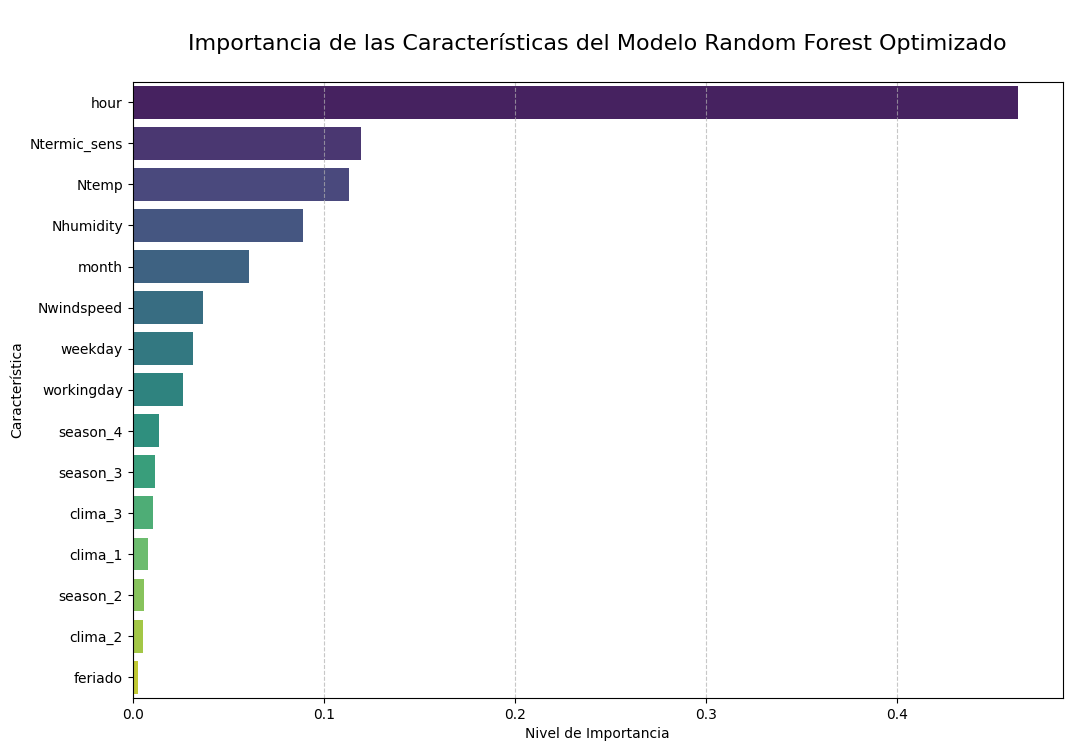

In [17]:
# Obtener Importancia de Características del mejor modelo Random Forest
feature_importances = best_rf_model.feature_importances_

# Obtener los nombres de las características.
feature_names = X_train.columns

# Crear una serie de pandas para mejor visualizacion
importances_df = pd.Series(feature_importances, index=feature_names).sort_values(ascending=False)

# Graficar la Importancia de caracteristicas
plt.figure(figsize=(12, 8))
sns.barplot(x=importances_df.values, y=importances_df.index, palette='viridis')
plt.title('\nImportancia de las Características del Modelo Random Forest Optimizado\n', size=16)
plt.xlabel('Nivel de Importancia')
plt.ylabel('Característica')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


### Entrenar y Evaluar Modelo XGBoost

Ahora, entrenaremos un modelo XGBoost Regressor y evaluaremos su rendimiento utilizando las métricas MAE, MSE, RMSE y R-squared en el conjunto de prueba para compararlo con el Random Forest.

In [18]:
# Importar el modelo XGBoost Regressor
import xgboost as xgb

# Inicializar el modelo XGBoost
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42, n_jobs=-1)

# Entrenar el modelo con los datos de entrenamiento
xgb_model.fit(X_train, y_train)

print("Modelo XGBoost entrenado con éxito.")

# Realizar predicciones sobre el conjunto de prueba (X_test)
y_pred_xgb = xgb_model.predict(X_test)

# Calcular métricas de evaluación para XGBoost
mae_xgb = metrics.mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = metrics.mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = metrics.r2_score(y_test, y_pred_xgb)

print(f"\n--- Métricas de XGBoost ---\n")
print(f"Mean Absolute Error (MAE): {mae_xgb:.2f}")
print(f"Mean Squared Error (MSE): {mse_xgb:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.2f}")
print(f"R-squared (R2): {r2_xgb:.2f}")


Modelo XGBoost entrenado con éxito.

--- Métricas de XGBoost ---

Mean Absolute Error (MAE): 89.69
Mean Squared Error (MSE): 15451.14
Root Mean Squared Error (RMSE): 124.30
R-squared (R2): 0.65


### Comparar Modelos y Discutir Resultados

Vamos a comparar los resultados de rendimiento del Random Forest optimizado y del modelo XGBoost para determinar cuál de ellos es el más adecuado para predecir la demanda de bicicletas.

In [19]:
print("--- Comparación de Métricas de Modelos ---\n")
print(f"\nRandom Forest (Baseline):")
print(f"  MAE: {mae_rf:.2f}")
print(f"  MSE: {mse_rf:.2f}")
print(f"  RMSE: {rmse_rf:.2f}")
print(f"  R2: {r2_rf:.2f}")

print(f"\nRandom Forest (Optimizado):")
print(f"  MAE: {mae_rf_optimized:.2f}")
print(f"  MSE: {mse_rf_optimized:.2f}")
print(f"  RMSE: {rmse_rf_optimized:.2f}")
print(f"  R2: {r2_rf_optimized:.2f}")

print(f"\nXGBoost:")
print(f"  MAE: {mae_xgb:.2f}")
print(f"  MSE: {mse_xgb:.2f}")
print(f"  RMSE: {rmse_xgb:.2f}")
print(f"  R2: {r2_xgb:.2f}")


# Summarize the findings
print("\n--- Conclusiones y Recomendaciones ---\n")
if r2_xgb > r2_rf_optimized:
    best_model = "XGBoost"
    best_r2 = r2_xgb
    mae_best = mae_xgb
    rmse_best = rmse_xgb
else:
    best_model = "Random Forest Optimizado"
    best_r2 = r2_rf_optimized
    mae_best = mae_rf_optimized
    rmse_best = rmse_rf_optimized

print(f"El modelo con mejor rendimiento es el **{best_model}** \
con un R-squared de {best_r2:.2f}.")
print(f"Esto indica que el {best_model} explica aproximadamente el {best_r2*100:.0f}% de la variabilidad\
\nen la demanda de bicicletas.")
print(f"\nSu Error Absoluto Medio (MAE) es de {mae_best:.2f}")
print(f"lo que significa que, en promedio, el modelo se equivoca en {mae_best:.2f} \
alquileres.")
print(f"\nEl Error Cuadrático Medio (RMSE) de {rmse_best:.2f} ")
print("sugiere una buena precisión general del modelo.")


--- Comparación de Métricas de Modelos ---


Random Forest (Baseline):
  MAE: 88.95
  MSE: 15750.17
  RMSE: 125.50
  R2: 0.64

Random Forest (Optimizado):
  MAE: 96.98
  MSE: 21721.84
  RMSE: 147.38
  R2: 0.50

XGBoost:
  MAE: 89.69
  MSE: 15451.14
  RMSE: 124.30
  R2: 0.65

--- Conclusiones y Recomendaciones ---

El modelo con mejor rendimiento es el **XGBoost** con un R-squared de 0.65.
Esto indica que el XGBoost explica aproximadamente el 65% de la variabilidad
en la demanda de bicicletas.

Su Error Absoluto Medio (MAE) es de 89.69
lo que significa que, en promedio, el modelo se equivoca en 89.69 alquileres.

El Error Cuadrático Medio (RMSE) de 124.30 
sugiere una buena precisión general del modelo.


###Recomendaciones futuras podrían incluir:
- **Más optimización de hiperparámetros:**   
  Realizar una búsqueda más exhaustiva de hiperparámetros para el modelo  
  ganador o incluso para otros modelos avanzados.

- **Ingeniería de características avanzada:**   
  Explorar la creación de nuevas características a partir de las existentes que puedan capturar mejor la estacionalidad, tendencias o eventos especiales no capturados actualmente.

 - **Validación cruzada de series de tiempo:** Utilizar técnicas de validación cruzada específicas para series de tiempo para obtener una estimación más robusta del rendimiento del modelo.

 - **Análisis de residuos:** Investigar los errores del modelo para identificar patrones o sesgos en las predicciones que puedan ser abordados.


###Análisis de Residuos para el Modelo XGBoost

El análisis de residuos es una herramienta crucial para evaluar la calidad de un modelo de regresión. Nos permite identificar si existen patrones no lineales que el modelo no ha capturado, si los errores son aleatorios e independientes, y si la varianza de los errores es constante (homocedasticidad).

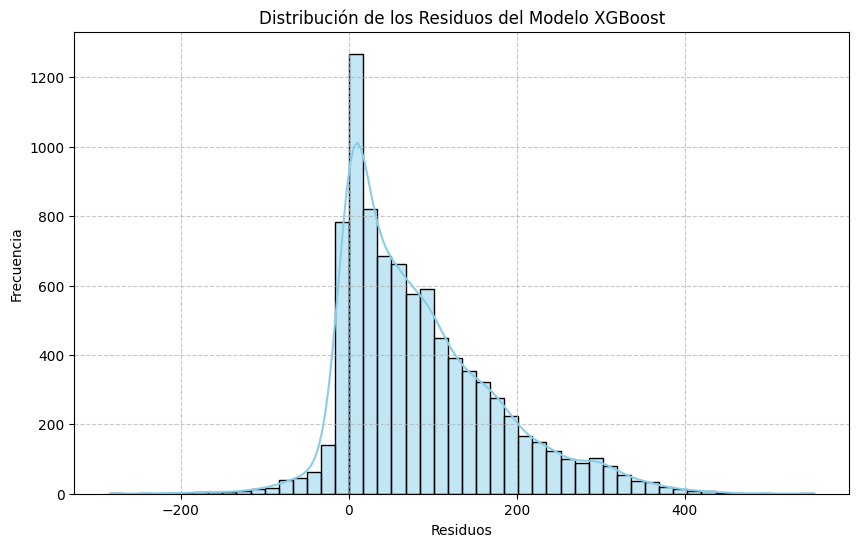

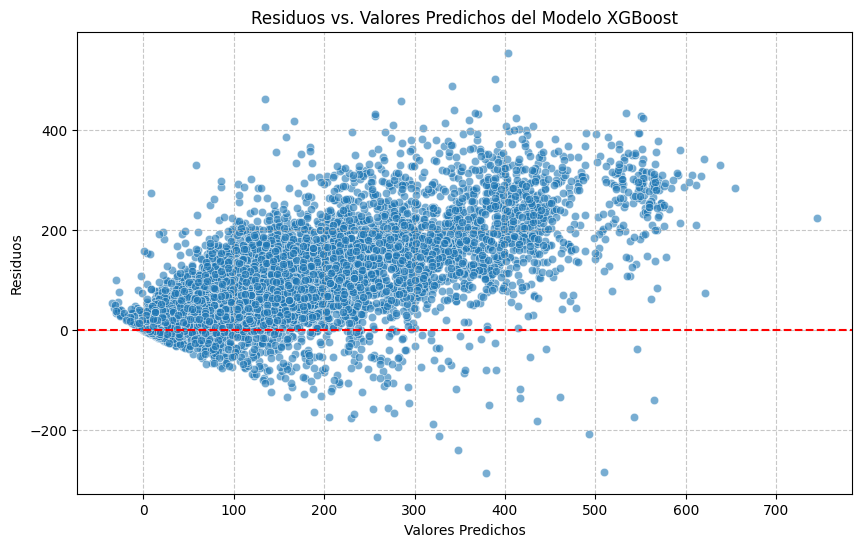

In [20]:
# Calcular los residuos del modelo XGBoost
residuals_xgb = y_test - y_pred_xgb

# Plotear un histograma de los residuos
plt.figure(figsize=(10, 6))
sns.histplot(residuals_xgb, kde=True, color='skyblue', bins=50)
plt.title('Distribución de los Residuos del Modelo XGBoost')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Plotear residuos vs. valores predichos
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_xgb, y=residuals_xgb, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuos vs. Valores Predichos del Modelo XGBoost')
plt.xlabel('Valores Predichos')
plt.ylabel('Residuos')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

El análisis de residuos para el modelo XGBoost, y los gráficos nos muestran lo siguiente:

  **Histograma de Residuos:** Vemos que la distribución de los residuos no es perfectamente normal; aunque tiene una forma de campana, presenta una ligera asimetría positiva.   
  Esto indica que el modelo tiende a subestimar la demanda de bicicletas en algunos casos, con errores positivos más grandes y frecuentes que los negativos. <br>
  <br>
  **Residuos vs. Valores Predichos:** En este gráfico, observamos un patrón que se asemeja a un cono o abanico, donde la dispersión de los residuos aumenta a medida que aumentan los valores predichos.    
  Esto es un indicador claro de heterocedasticidad, lo que significa que el modelo comete errores más grandes para predicciones de alta demanda. Idealmente, los residuos deberían estar dispersos aleatoriamente alrededor de cero sin ningún patrón.    
  También hay una ligera tendencia no lineal, lo que sugiere que el modelo podría no haber capturado completamente algunas relaciones en los datos, especialmente para valores de demanda más bajos. <br>
<br>
En resumen: Aunque el XGBoost tuvo el mejor rendimiento en términos de R-squared y otras métricas, el análisis de residuos sugiere que aún hay margen de mejora. La heterocedasticidad y la asimetría en los residuos indican que el modelo podría beneficiarse de:

Transformación de la variable objetivo: Aplicar una transformación (como la raíz cuadrada o el logaritmo) a la variable objetivo <font color="red">`count`</font> podría ayudar a estabilizar la varianza y hacer que los residuos sean más homoscedásticos y normales.<br>
<br>
**Modelos más avanzados:** Considerar modelos que manejen mejor la distribución de conteo o la heterocedasticidad, como los modelos de regresión de Poisson o modelos aditivos generalizados (GAM).<br>
<br>
**Optimización de hiperparámetros más profunda:** Una búsqueda más exhaustiva de hiperparámetros para XGBoost podría encontrar una configuración que reduzca estos patrones en los residuos.

## Pipeline con GridSearchCV para XGBoost

Creamos un `Pipeline` para el modelo XGBoost, incluyendo un `StandardScaler` para normalizar las características numéricas antes de alimentar el modelo. Esto asegura que cada paso del preprocesamiento se aplique correctamente dentro de la validación cruzada.

Luego, utilizaremos `GridSearchCV` para una búsqueda exhaustiva de hiperparámetros en el pipeline, lo que nos permitirá encontrar la mejor combinación de parámetros para el escalador y el modelo XGBoost de manera sistemática y con validación cruzada.

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

# 1. Definir el Pipeline: Escalador + XGBoost Regressor
# Definimos el nombre de los pasos 'scaler' y 'xgbregressor'
pipeline_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('xgbregressor', xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1))
])

# 2. Definir la cuadrícula de hiperparámetros para GridSearchCV
# Los nombres de los parámetros deben seguir el formato
#'nombre_del_paso__nombre_del_parametro'
param_grid_xgb = {
    'xgbregressor__n_estimators': [100, 200, 300],
    'xgbregressor__max_depth': [3, 5, 7],
    'xgbregressor__subsample': [0.7, 0.8, 0.9],
    'xgbregressor__colsample_bytree': [0.7, 0.8, 0.9]
}

# 3. Inicializar GridSearchCV con el pipeline y la cuadrícula de parámetros
# n_jobs=-1 para usar todos los núcleos disponibles
grid_search_xgb = GridSearchCV(estimator=pipeline_xgb,
                               param_grid=param_grid_xgb,
                               cv=5,  # Usamos 5-fold cross-validation
                               scoring='r2', # Métrica de evaluación
                               verbose=2, # Mostrar el progreso
                               n_jobs=-1)

# 4. Ajustar GridSearchCV a los datos de entrenamiento
print("Iniciando GridSearchCV para XGBoost...")
grid_search_xgb.fit(X_train, y_train)

# 5. Imprimir los mejores parámetros y la mejor puntuación
print("\nMejores parámetros encontrados por GridSearchCV para XGBoost:")
print(grid_search_xgb.best_params_)
print("\nMejor puntuación R2 (en validación cruzada) para XGBoost:")
print(f"{grid_search_xgb.best_score_:.2f}")


Iniciando GridSearchCV para XGBoost...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Mejores parámetros encontrados por GridSearchCV para XGBoost:
{'xgbregressor__colsample_bytree': 0.7, 'xgbregressor__max_depth': 5, 'xgbregressor__n_estimators': 100, 'xgbregressor__subsample': 0.7}

Mejor puntuación R2 (en validación cruzada) para XGBoost:
0.81


### Evaluar el Mejor Modelo XGBoost del Pipeline

Una vez que `GridSearchCV` ha encontrado la mejor combinación de hiperparámetros, podemos extraer el mejor modelo (`best_estimator_`) del `grid_search_xgb` y evaluar su rendimiento final en el conjunto de prueba (`X_test`, `y_test`).

In [27]:
# Obtener el mejor modelo del GridSearchCV
best_pipeline_xgb = grid_search_xgb.best_estimator_

# Realizar predicciones sobre el conjunto de prueba con el mejor pipeline
y_pred_xgb_tuned = best_pipeline_xgb.predict(X_test)

# Calcular métricas de evaluación para el modelo XGBoost optimizado
mae_xgb_tuned = metrics.mean_absolute_error(y_test, y_pred_xgb_tuned)
mse_xgb_tuned = metrics.mean_squared_error(y_test, y_pred_xgb_tuned)
rmse_xgb_tuned = np.sqrt(mse_xgb_tuned)
r2_xgb_tuned = metrics.r2_score(y_test, y_pred_xgb_tuned)

print(f"--- Métricas de XGBoost Optimizado (con Pipeline y GridSearchCV) ---\n")
print(f"\nMean Absolute Error (MAE): {mae_xgb_tuned:.2f}")
print(f"Mean Squared Error (MSE): {mse_xgb_tuned:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb_tuned:.2f}")
print(f"R-squared (R2): {r2_xgb_tuned:.3f}")

--- Métricas de XGBoost Optimizado (con Pipeline y GridSearchCV) ---


Mean Absolute Error (MAE): 91.26
Mean Squared Error (MSE): 16004.52
Root Mean Squared Error (RMSE): 126.51
R-squared (R2): 0.633


### Comparación Final de Modelos

Ahora podemos comparar el rendimiento de este modelo XGBoost optimizado con los resultados de los modelos anteriores.

In [30]:
print("--- Comparación de Métricas de Modelos ---\n")
print(f"\nRandom Forest (Baseline):")
print(f"  MAE: {mae_rf:.2f}")
print(f"  MSE: {mse_rf:.2f}")
print(f"  RMSE: {rmse_rf:.2f}")
print(f"  R2: {r2_rf:.2f}")

print(f"\nRandom Forest (Optimizado - RandomizedSearchCV):")
print(f"  MAE: {mae_rf_optimized:.2f}")
print(f"  MSE: {mse_rf_optimized:.2f}")
print(f"  RMSE: {rmse_rf_optimized:.2f}")
print(f"  R2: {r2_rf_optimized:.2f}")

print(f"\nXGBoost (Baseline):")
print(f"  MAE: {mae_xgb:.2f}")
print(f"  MSE: {mse_xgb:.2f}")
print(f"  RMSE: {rmse_xgb:.2f}")
print(f"  R2: {r2_xgb:.2f}")

print(f"\nXGBoost (Optimizado - Pipeline + GridSearchCV):")
print(f"  MAE: {mae_xgb_tuned:.2f}")
print(f"  MSE: {mse_xgb_tuned:.2f}")
print(f"  RMSE: {rmse_xgb_tuned:.2f}")
print(f"  R2: {r2_xgb_tuned:.2f}")


# Determinar el mejor modelo
metrics_dict = {
    "Random Forest (Baseline)": {"R2": r2_rf, "MAE": mae_rf, "RMSE": rmse_rf},
    "Random Forest (Optimizado)": {"R2": r2_rf_optimized, "MAE": mae_rf_optimized, "RMSE": rmse_rf_optimized},
    "XGBoost (Baseline)": {"R2": r2_xgb, "MAE": mae_xgb, "RMSE": rmse_xgb},
    "XGBoost (Optimizado - Pipeline + GridSearchCV)": {"R2": r2_xgb_tuned, "MAE": mae_xgb_tuned, "RMSE": rmse_xgb_tuned}
}

best_model_name = max(metrics_dict, key=lambda k: metrics_dict[k]["R2"])
best_r2_final = metrics_dict[best_model_name]["R2"]
best_mae_final = metrics_dict[best_model_name]["MAE"]
best_rmse_final = metrics_dict[best_model_name]["RMSE"]

print("\n--- Conclusiones Finales y Recomendaciones ---\n")

print(f"\nEl modelo con mejor rendimiento general es el **{best_model_name}** \
con un R-squared de {best_r2_final:.2f}.")
print(f"Este modelo explica aproximadamente el {best_r2_final*100:.0f}% de \
la variabilidad en la demanda de bicicletas.")
print(f"Su Error Absoluto Medio (MAE) es de {best_mae_final:.2f}, y el RMSE de {best_rmse_final:.2f}.")

print("\n\n")

--- Comparación de Métricas de Modelos ---


Random Forest (Baseline):
  MAE: 88.95
  MSE: 15750.17
  RMSE: 125.50
  R2: 0.64

Random Forest (Optimizado - RandomizedSearchCV):
  MAE: 96.98
  MSE: 21721.84
  RMSE: 147.38
  R2: 0.50

XGBoost (Baseline):
  MAE: 89.69
  MSE: 15451.14
  RMSE: 124.30
  R2: 0.65

XGBoost (Optimizado - Pipeline + GridSearchCV):
  MAE: 91.26
  MSE: 16004.52
  RMSE: 126.51
  R2: 0.63

--- Conclusiones Finales y Recomendaciones ---


El modelo con mejor rendimiento general es el **XGBoost (Baseline)** con un R-squared de 0.65.
Este modelo explica aproximadamente el 65% de la variabilidad en la demanda de bicicletas.
Su Error Absoluto Medio (MAE) es de 89.69, y el RMSE de 124.30.





## Resumen de Métricas de Modelos

In [35]:
# Crear un diccionario con todas las métricas
all_metrics = {
    'Modelo': [
        'Regresión Lineal',
        'Random Forest (Baseline)',
        'Random Forest (Optimizado)',
        'XGBoost (Baseline)',
        'XGBoost (Optimizado con Pipeline)'
    ],
    'MAE': [
        mae,
        mae_rf,
        mae_rf_optimized,
        mae_xgb,
        mae_xgb_tuned
    ],
    'MSE': [
        mse,
        mse_rf,
        mse_rf_optimized,
        mse_xgb,
        mse_xgb_tuned
    ],
    'RMSE': [
        rmse,
        rmse_rf,
        rmse_rf_optimized,
        rmse_xgb,
        rmse_xgb_tuned
    ],
    'R2': [
        r2,
        r2_rf,
        r2_rf_optimized,
        r2_xgb,
        r2_xgb_tuned
    ]
}

# Crear el DataFrame
metrics_df = pd.DataFrame(all_metrics)

# Formatear las columnas numéricas para una mejor visualización
metrics_df[['MAE', 'MSE', 'RMSE', 'R2']] = metrics_df[['MAE', 'MSE', 'RMSE', 'R2']].round(2)


def highlight_best_model(s):
    # Highlights the 'XGBoost (Baseline)'

    # Chequea si valor "Modelo" value en fila actual coincide
    if s['Modelo'] == 'XGBoost (Baseline)':
        # si coincide, retorna una lista de 'background-color: lightgreen'
        # para cada columna en la fila.
        # la longitud de esta lista debe coincidir con numero de columns en 's'
        return ['background-color: lightgreen'] * len(s)
    else:
        # de lo contrario, retornar cadena vacia para cada columna (sin style)
        return [''] * len(s)

# Aplicar el estilo al DataFrame y mostrarlo
display(metrics_df.style.apply(highlight_best_model, axis=1))

,Modelo,MAE,MSE,RMSE,R2
0,Regresión Lineal,129.720000,36390.110000,190.760000,0.170000
1,Random Forest (Baseline),88.950000,15750.170000,125.500000,0.640000
2,Random Forest (Optimizado),96.980000,21721.840000,147.380000,0.500000
3,XGBoost (Baseline),89.690000,15451.140000,124.300000,0.650000
4,XGBoost (Optimizado con Pipeline),91.260000,16004.520000,126.510000,0.630000


*<font color="darkred"> Un **R2** más alto y un MAE más bajo (y también RMSE más bajo) indican un modelo con un mejor rendimiento.</font>*

Las **recomendaciones futuras** podrían incluir:
- Explorar transformaciones de la variable objetivo (`count`) para abordar la heterocedasticidad y la asimetría en los residuos, como se observó en el análisis de residuos."

- Considerar modelos alternativos que manejen mejor las distribuciones de conteo (por ejemplo, modelos de regresión de Poisson o Negative Binomial).

- Realizar una ingeniería de características más avanzada para capturar patrones temporales complejos (tendencias, estacionalidades múltiples, etc.)

- Investigar la inclusión de otras fuentes de datos que puedan impactar la demanda de bicicletas (eventos especiales, días festivos específicos, etc.)

<br>

# Conclusiones


Se probaron varios modelos `Regresión Lineal` , `Random Forest` y `XGBoost`    

El que tuvo mejor desempeño es XGBoost seguido de un Random Forest básico (no se consiguió mejoras a través de GridSearchCV).   

El bajo desempeño de estos modelos, creo se basa en variables ocultas, no presentes en el dataset.
Que estarían fuertemente relacionadas con la variable objetivo `count` y que sólo se manifiestan con su presencia.
Al no estar presente esta variable en el entrenamiento, el mayor aporte a la predicción, se pierde.


Algunas de estas variables podrían ser:  

- **Mayor cantidad de bicicletas disponibles para alquilar**
- **Nuevas estaciones de entrega/retiro de bicicletas en la ciudad y alrededores.**
- **Campañas de marketing promoviendo el uso sustentable del transporte en bicicleta**
- **Campaña de registración de nuevos usuarios y/o fidelización de los usuarios existentes**<br><br>


<font color="darkgreen">&emsp;&emsp;Esto se constató parcialmente al analizar las variables de temperatura, clima,  <br>
&emsp;&emsp;y también estacionales del año 2011 usado para el entrenamiento, y del año 2012 <br>
&emsp;&emsp;usado para hacer las predicciones.   
&emsp;&emsp;No se observaron diferencias significativas entre estas variables,  que pudieran <br>
&emsp;&emsp;explicar el gran aumento (64%) en los alquileres efectuados en 2012, respecto a 2011.   
&emsp;&emsp;Estos datos y los gráficos se encuentran en otro Colab. </font>

<br>

Llegado a este punto, me pregunto si no hubiese sido mejor usar otros modelos más adecuados de ML, para hacer las estimaciones / predicciones.   
 <br>

Probablemente hubiese sido mejor adoptar un enfoque basado en `Series de Tiempo` y usando modelos autoregresivos.

El dataset de "shared-bikes" presenta varias caracteristicas como: falta de`Estacionaridad` (valores no estacionarios), `Estacionalidad` (sensible a cambios estacionales) y `Tendencia` positiva (una varianza que aumenta), que parece ser mejor abordada, por esta clase de modelos como: **ARIMA** (Autoregressive Integrated Moving Average (Media Móvil Integrada Autorregresiva) y **SARIMA** (ARIMA estacional)  

ARIMA combina tres técnicas para prever valores futuros basándose en datos históricos:

- **Autorregresión** (AR): Utiliza los valores pasados de la propia variable para predecir los futuros (parámetro p).    

- **Integración** (I): Aplica diferenciación (restar el valor actual con el anterior) para estabilizar los datos y eliminar tendencias (parámetro d). Esto permite que el modelo funcione con datos no estacionarios   

- **Media móvil** (MA): Modela el error de predicción utilizando los residuos o errores pasados (parámetro q)    

<br>

Otra posibilidad es usar librerias dedicadas como **Prophet o Dart**, algo que por el momento esta fuera de alcance.   



## Observaciones Finales

Luego de finalizar el modelo, se buscaron datos que pudieran explicar las
diferencias obtenidas de las predicciones de los modelos usados.

En Abril 2011:
- 114 estaciones
- 11.000 miembros
- 1100 bicicletas

Para septiembre de 2012:
- **288** estaciones
- **20000** miembros
- **2800** bicicletas en cuatro jurisdicciones

No se pudo obtener datos de las campañas de marketing, aparentemente fueron bastante intensas.  

###<font color="#cc00cc">Observamos que prácticamente se duplicaron la cantidad de bicicletas, estaciones de alquiler y los usuarios registrados !</font>

Esto termina de confirmar la sospecha, por qué los datos, salvo la **cantidad de alquileres** representada por la variable `count`, no explicaban el aumento de la renta de bicicletas.
# &#x01F600;

<br>
<center> -o-O-o-</center>